# Batched Atomistic Simulation with NVIDIA ALCHEMI

<p align="center"><img src="assets/images/banner_adsorbml_toolkit_abstract_spheres.png" alt="Abstract GPU batching search landscape" style="max-width: 1360px; width: 100%; height: auto;"></p>

<!-- **Runtime target:** ALCHEMI Toolkit on a CUDA GPU  
**Teaching path:** batched MLIP relaxation with explicit structure, energy, and validation checkpoints  
**Companion check:** [OC20Dense accuracy and reproducibility](oc20dense-accuracy-reproducibility-check.ipynb) -->

*This tutorial uses adsorption configuration search as a concrete example of a broader shift: batched, GPU-native atomistic simulation lets a researcher run throughput calculations on a single modern GPU, then move better-ranked structures into whatever downstream review or validation path the project requires.*

**What you will do**

1. Use a small H<sub>2</sub>O example to see how batching changes runtime.
2. Run a limited OC20Dense reproducibility and model-sanity check against released DFT trajectories.
3. Build chemically meaningful adsorption starting structures.
4. Relax, rank, visualize, and interpret the final adsorption geometries.

## Chemical discovery starts as a search problem

Chemical discovery begins with an enormous, almost limitless solution space. A research goal can branch across composition, molecular structure, crystal structure, environment, target property, and practical constraints such as cost, safety, synthesis route, or lifetime. The first step is therefore not to run a model; those come soon. It is to define a meaningful search space.

A useful computational workflow narrows that space in stages:

- **Frame the scientific question.** Decide what is being optimized or rationalized: stability, selectivity, conductivity, degradation, binding, diffusion, emission, or another property.
- **Apply chemical judgement.** Use known chemistry, physics, synthesis constraints, and domain knowledge (human or even agentic) to remove candidates that are irrelevant or impossible for the intended application.
- **Define the candidate set.** Turn the remaining ideas into "chemistry" that can be simulated: molecules, conformers, crystals, defects, interfaces, reaction states, adsorption geometries, or other local atomic arrangements.
- **Choose the evidence ladder.** Decide which results are screening signals, which need stronger evidence outside this notebook, and what metadata is needed before two numbers can be compared.

Even after this narrowing, the candidate set can still contain hundreds, thousands, or millions of structures. The practical bottleneck is no longer only the model; it is the ability to evaluate many reasonable structures without turning every idea into a separate campaign.

This is where batching changes the practical landscape. Instead of turning every exploratory idea into a separate calculation campaign, large sets of MLIP relaxations can now run as throughput calculations on a single modern GPU.

Surface adsorption gives this general search problem a concrete shape. Once a molecule-on-surface question is selected, the workflow still has to choose the slab model: composition, Miller index, termination, supercell, coverage, frozen-layer convention, and surface preparation. Only then does the local configuration search begin: adsorption sites, molecular orientation, height, and sometimes multiple starting geometries for the same chemical idea. Adsorption is part of many real discovery pipelines: catalysis, separations, water harvesting, OER materials, framework materials, and surface chemistry. ALCHEMI enters at this point to help researchers navigate solution spaces of interest with GPU-native batched workflows.



<p align="center"><img src="assets/images/discovery_funnel.png" alt="Chemical discovery funnel" style="max-width: 1200px; width: 100%; height: auto;"></p>

## Where NVIDIA ALCHEMI fits

NVIDIA ALCHEMI — the AI Lab for Chemistry and Materials Innovation — is built around a clear mission: accelerate chemistry and materials discovery with AI. In practice, ALCHEMI brings together delivery modes such as domain-specific NIM microservices with Toolkit building blocks and Toolkit-Ops kernels for AI-enabled atomistic simulation. This tutorial focuses on the direct Toolkit path: use familiar Python structure tools, convert structures into Toolkit data objects, and run batched GPU geometry relaxations that are easy to inspect and extend.

ALCHEMI provides Toolkit data structures, optimizers, simulation components, and GPU kernels that can connect to familiar and established structure pipelines. In this notebook, the practical value is **batched**, **customizable**, **GPU-native** execution: familiar structure objects in, batched relaxation and simulation out.

The ALCHEMI pieces used in this tutorial are:

- <span style="color:#76b900"><strong>Toolkit</strong></span> **Direct Python workflow.** This notebook uses the ALCHEMI Toolkit API: build structures with ASE/pymatgen, convert them into `AtomicData`, pack them into a `Batch`, run a model and optimizer, then inspect the relaxed structures and metadata in Python.
- <span style="color:#00a3e0"><strong>Toolkit-Ops</strong></span> **Accelerated operations under the hood.** Toolkit-Ops is the GPU-kernel layer for common batched atomistic operations such as neighbor lists, DFT-D3 dispersion corrections, and long-range electrostatics. The tutorial does not ask readers to call Toolkit-Ops directly, but it is part of the ALCHEMI stack that makes high-throughput simulation practical.
- **Pluggable MLIPs.** The surface screen uses the surface-specialized `mh-1 + oc20_usemppbe` model, while the batch-size calibration keeps `medium-mpa-0` as a comparison point. In other ALCHEMI workflows, the model can change with the chemistry while the batching, metadata, and verification pattern remains the same.

The discovery loop is the complete cycle: define a candidate set, generate valid structures with established tools, run batched GPU relaxations or simulations, rank reliable outputs, inspect failures, and decide which cases are ready for the next project-specific review step.

<mark>TODO - VISUAL REVIEW</mark>: Polish or replace this workflow graphic once the final presentation visuals are selected.


<p align="center"><img src="assets/images/alchemi_toolkit_community_ops.png" alt="ALCHEMI Toolkit and Toolkit-Ops architecture" style="max-width: 1240px; width: 100%; height: auto;"></p>

## Tools at a glance

Before the code starts, here is the role of each scientific tool in this workflow. The stack is intentionally interoperable: use familiar structure tools, accelerate the bottleneck, and keep the outputs inspectable.

| Tool | What it does here |
|---|---|
| **NVIDIA GPU/CUDA** | Supplies the accelerated execution layer that makes many independent relaxations practical as a throughput calculation on one GPU. |
| **ALCHEMI Toolkit** | Connects atomistic structures to batched GPU execution, model wrappers, optimizers, constraints, and workflow metadata. |
| **MACE MLIPs** | Evaluate energies and forces for periodic slab and molecule calculations. The adsorption screen uses the surface-specialized `mh-1 + oc20_usemppbe` model; the batch-size calibration also shows the trade-off against `medium-mpa-0`. |
| **AdsorbML-style search** | Provides the workflow pattern: generate many plausible adsorbate placements, relax them, rank the final structures, and inspect failures instead of trusting one initial guess. |
| **ASE** | Builds and stores atomistic structures in Python: gas molecules, slabs, adsorbate-slab starts, and relaxed outputs. |
| **pymatgen** | Builds crystal surfaces and terminations from bulk crystal structures, especially for oxide slabs where the surface model matters. |
| **OVITO** | Renders structures for human inspection so ranking results can be checked against the actual geometry. |


## Why configuration search matters

<p align="center"><img src="assets/images/workflow_gpu_batching_with_gpu.png" alt="GPU batching search landscape" style="max-width: 1120px; width: 100%; height: auto;"></p>

<mark>TODO - VISUAL REVIEW</mark>: Polish or replace this workflow graphic once the final presentation visuals are selected.

Surface adsorption makes the search problem easy to see. A molecule can approach the same surface through different atoms, different orientations, and different sites. Several starts may look chemically reasonable, but after relaxation they can settle into different local minima.

AdsorbML is the reference point for this tutorial, not a first-of-kind claim. The 2023 AdsorbML study showed a practical shift for adsorption-energy workflows: instead of relaxing one manually chosen pose, generate many plausible adsorbate-surface configurations, use ML potentials to relax or filter them, and spend higher-fidelity effort on the resulting shortlist. One balanced setting reported finding the lowest-energy configuration 87.36% of the time with about a 2000x speedup ([Lan et al., 2023](https://doi.org/10.1038/s41524-023-01121-5)).

This tutorial borrows that workflow logic. After the surface model is chosen, the calculation enumerates a local adsorption parameter space: candidate sites, orientations, heights, and related starting geometries. The goal is not to trust one plausible initial guess, but to search the defined configuration space and identify the lowest-energy relaxed structure found within it.

A batched search therefore asks a more useful question:

> **Given this surface model and adsorption parameter space, what is the best relaxed structure the workflow can find?**

ALCHEMI makes that search practical by running many independent starting structures as a batched GPU workflow, so the parameter sweep becomes part of the calculation rather than an informal manual preselection.

The same logic appears across many chemical domains. For adsorption it is sites and orientations. For molecules it may be conformers or protonation states. For materials it may be defects, terminations, dopants, interfaces, or local atomic arrangements. In catalysis, separations, water harvesting, OER frameworks, and surface chemistry, batching makes it practical to test many candidates instead of treating one starting structure as an invisible assumption.


## Choose a model, then verify it

Batched relaxation only helps if the model is suitable for the chemistry being searched. Here that means an MLIP that has seen surface chemistry and can handle adsorbate--slab geometries well enough to support screening.

So the tutorial first makes the batching pattern concrete with a small H<sub>2</sub>O example, then runs a limited OC20Dense reproducibility and model-sanity check on surface-adsorption cases related to the workflow. The OC20Dense checkpoint uses released DFT trajectories: exact starting structures, DFT-relaxed final structures, DFT-level adsorption-energy targets, clean-slab references, gas references, MACE single-point energies, and Toolkit relaxations can all be audited from dataset-backed files.

The opening workflow is:

- choose a surface-chemistry-capable MLIP;
- check energy and relaxation behavior on known DFT trajectory data;
- generate a batched adsorption search for the systems we want to explore;
- relax, rank, and inspect the resulting geometries.

The companion [OC20Dense accuracy and reproducibility notebook](oc20dense-accuracy-reproducibility-check.ipynb) keeps the deeper audit in one place: source-structure reruns, DFT trajectory arithmetic, MACE adsorption-energy subtraction, parity plots, and OVITO structure checks.

<mark>TODO - REFERENCE REVIEW</mark>: Before turning contextual literature comparisons in the generated adsorption panel into quantitative claims, match the adsorbate, surface/facet or termination, coverage, functional, dispersion treatment, frozen-layer convention, and adsorption-energy sign convention.

---

## Control panel

Use this cell to choose how the notebook will run. Later cells read these same settings, so one edit here changes the whole workflow.

The choices below are plain Python variables. Edit the values directly in the next cell.

There are two compute scopes:

- `RUN_SCOPE = "short"` runs one representative adsorption example with six starting structures. Use it to check the workflow, kernel, GPU connection, and result tables quickly.
- `RUN_SCOPE = "full"` runs the complete active adsorption grid defined in this notebook. Use it when you want the full site and orientation search for every adsorbate-surface example.

There are also two result sources:

- `TUTORIAL_RESULT_SOURCE = "compute"` recomputes the main tutorial workflow into a timestamped live run. Set it to `"saved"` when you want to read saved tutorial outputs instead.
- `VALIDATION_RESULT_SOURCE = "compute"` reruns the OC20Dense validation checks. Set it to `"saved"` when you only want to inspect the saved validation tables.

`SAVED_TUTORIAL_RUN_ID` and `SAVED_ACCURACY_RUN_ID` let you reopen one explicit timestamped live run. Leave them `None` to use the official saved cache, or set `"latest-complete"` to use the newest live run that passes completeness checks.

`REFRESH_SAVED_RESULTS` is the intentional overwrite switch for official saved artifacts. Leave it `False` for presentation or exploratory reruns; set it `True` only when you mean to regenerate the official saved outputs.

This version is Toolkit-only: relaxations run through the ALCHEMI Toolkit on the cluster GPU.

D3 is available in Toolkit workflows, but it is disabled here because the OC20Dense validation data follows the non-D3 OC20 convention. If you enable D3 for another dataset or application, record the explicit parameters in the run metadata.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
from datetime import datetime

# === Run choices ===========================================================

# "short" checks the workflow with one small example.
# "full" runs the complete active grid defined in this notebook.
RUN_SCOPE = "full"

VALID_RUN_SCOPES = {"short", "full"}
if RUN_SCOPE not in VALID_RUN_SCOPES:
    raise ValueError(f"RUN_SCOPE must be one of {sorted(VALID_RUN_SCOPES)}, got {RUN_SCOPE!r}")
RUN_SCOPE_LABEL = {
    "short": "short check",
    "full": "full grid",
}[RUN_SCOPE]

# Choose whether each part recomputes results or reads saved outputs.
# "compute" writes to a timestamped live run by default; "saved" reads the
# official cache unless a SAVED_*_RUN_ID below selects a previous live run.
TUTORIAL_RESULT_SOURCE = "compute"     # "compute" or "saved"
VALIDATION_RESULT_SOURCE = "compute"   # "compute" or "saved"

VALID_RESULT_SOURCES = {"compute", "saved"}
for name, value in {
    "TUTORIAL_RESULT_SOURCE": TUTORIAL_RESULT_SOURCE,
    "VALIDATION_RESULT_SOURCE": VALIDATION_RESULT_SOURCE,
}.items():
    if value not in VALID_RESULT_SOURCES:
        raise ValueError(f"{name} must be one of {sorted(VALID_RESULT_SOURCES)}, got {value!r}")

# Derived helper flag for tutorial output routing. Validation uses
# VALIDATION_RESULT_SOURCE directly so the benchmark switch stays readable.
USE_SAVED_TUTORIAL_RESULTS = TUTORIAL_RESULT_SOURCE == "saved"

# Leave these as None for the official saved cache. Set one explicit timestamp
# to reopen a previous live run, for example "20260518-143022".
# Set "latest-complete" only when you want the newest live run that passes
# the required-file checks for this scope.
SAVED_TUTORIAL_RUN_ID = None
SAVED_ACCURACY_RUN_ID = None

# Intentional overwrite switch for official saved artifacts.
# Leave False for presentation and exploratory runs. Set True only when you
# mean to regenerate the official saved tutorial/benchmark outputs.
REFRESH_SAVED_RESULTS = False

LIVE_RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")
if REFRESH_SAVED_RESULTS:
    TUTORIAL_RESULT_SOURCE = "compute"
    VALIDATION_RESULT_SOURCE = "compute"
    USE_SAVED_TUTORIAL_RESULTS = False
    SAVED_TUTORIAL_RUN_ID = None
    SAVED_ACCURACY_RUN_ID = None

# The computational story does not depend on local rendering. Leave this False
# on a headless workstation; set True when VisRTX is available and you want
# result structure images regenerated inside the notebook.
REQUIRE_VISRTX_RENDER = False

# Label used in result tables and run metadata.
EXECUTION_PATH = "toolkit"


In [3]:
# Keep generated files, helper imports, and package caches anchored to the tutorial workspace.
# === Notebook housekeeping =================================================
import importlib
import os
import sys
from pathlib import Path


def find_tutorial_root(start: Path | None = None) -> Path:
    """Find the notebook folder from common Jupyter launch directories."""
    start = (start or Path.cwd()).resolve()

    def is_tutorial_root(path: Path) -> bool:
        return (
            (path / "helpers" / "__init__.py").exists()
            and (path / "assets").exists()
            and (path / "alchemi-mace-adsorption-search.ipynb").exists()
        )

    for candidate in (start, *start.parents):
        if is_tutorial_root(candidate):
            return candidate

    for child in sorted(p for p in start.iterdir() if p.is_dir()):
        if is_tutorial_root(child):
            return child

    raise RuntimeError(
        "Could not find the tutorial folder. Start Jupyter from either the "
        "repository root or the folder that contains helpers/, assets/, and "
        "alchemi-mace-adsorption-search.ipynb."
    )


TUTORIAL_ROOT = find_tutorial_root()
os.chdir(TUTORIAL_ROOT)
if str(TUTORIAL_ROOT) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_ROOT))

# If the kernel saw an older helper package before this cell was fixed, clear it
# so the import below comes from the helper files beside this notebook.
for module_name in [name for name in list(sys.modules) if name == "helpers" or name.startswith("helpers.")]:
    del sys.modules[module_name]
importlib.invalidate_caches()

from helpers import (
    list_live_runs,
    resolve_run_roots,
    write_artifact_index,
    write_run_manifest,
)

RUN_ROOTS = resolve_run_roots(
    tutorial_root=TUTORIAL_ROOT,
    run_scope=RUN_SCOPE,
    use_saved_tutorial_results=USE_SAVED_TUTORIAL_RESULTS,
    use_saved_accuracy_results=(VALIDATION_RESULT_SOURCE == "saved"),
    saved_tutorial_run_id=SAVED_TUTORIAL_RUN_ID,
    saved_accuracy_run_id=SAVED_ACCURACY_RUN_ID,
    refresh_saved_results=REFRESH_SAVED_RESULTS,
    live_run_id=LIVE_RUN_ID,
)

# === Local paths ===========================================================
PRECOMPUTED_OUTPUT_DIR = "outputs/precomputed"
PRECOMPUTED_TUTORIAL_OUTPUT_DIR = RUN_ROOTS.official_tutorial_root.as_posix()
PRECOMPUTED_ACCURACY_OUTPUT_DIR = RUN_ROOTS.official_accuracy_root.as_posix()
LIVE_OUTPUT_DIR = RUN_ROOTS.live_root.as_posix()
TUTORIAL_OUTPUT_DIR = RUN_ROOTS.tutorial_output_dir.as_posix()
ACCURACY_OUTPUT_DIR = RUN_ROOTS.accuracy_output_dir.as_posix()
CACHE_DIR = RUN_ROOTS.cache_dir.as_posix()
PLOTS_DIR = RUN_ROOTS.plots_dir.as_posix()
RUNTIME_CACHE_DIR = RUN_ROOTS.runtime_cache_dir.as_posix()
OUTPUT_DIR = TUTORIAL_OUTPUT_DIR
SURFACE_SCREEN_OUTPUT_ROOT = RUN_ROOTS.surface_screen_root.as_posix()

ASSETS_DIR = "assets"
IMAGES_DIR = os.path.join(ASSETS_DIR, "images")
PRESENTATION_PLOTS_DIR = os.path.join(PRECOMPUTED_TUTORIAL_OUTPUT_DIR, "plots")

# Keep model and library caches beside the notebook so setup is repeatable.
os.environ.setdefault("XDG_CACHE_HOME", str(TUTORIAL_ROOT / RUNTIME_CACHE_DIR / "xdg"))
os.environ.setdefault("TORCH_HOME", str(TUTORIAL_ROOT / RUNTIME_CACHE_DIR / "torch"))
os.environ.setdefault("HF_HOME", str(TUTORIAL_ROOT / RUNTIME_CACHE_DIR / "hf"))
os.environ.setdefault("WARP_CACHE_PATH", str(TUTORIAL_ROOT / RUNTIME_CACHE_DIR / "warp"))
os.environ["REFRESH_SAVED_RESULTS"] = "1" if REFRESH_SAVED_RESULTS else "0"
_OVERWRITE_FLAG = "1" if REFRESH_SAVED_RESULTS else "0"
os.environ["ALCHEMI_ALLOW_ARTIFACT_OVERWRITE"] = _OVERWRITE_FLAG

print(f"Tutorial root                     : {TUTORIAL_ROOT}")
print(f"Tutorial output source            : {RUN_ROOTS.tutorial_source_label}")
print(f"Accuracy output source            : {RUN_ROOTS.accuracy_source_label}")
print(f"Live run root                     : {LIVE_OUTPUT_DIR}")
recent_live_runs = list_live_runs(TUTORIAL_ROOT, run_scope=RUN_SCOPE)
if recent_live_runs:
    print("Recent live runs:")
    for row in recent_live_runs[:5]:
        print(
            f"  {row['run_id']} | scope={row['run_scope']} | "
            f"tutorial_complete={row['tutorial_complete']} | "
            f"accuracy_complete={row['accuracy_complete']}"
        )


Tutorial root                     : /home/nfedik/projects/tutorials/part-1-batched-adsorption
Tutorial output source            : new live run 20260518-014249
Accuracy output source            : new live run 20260518-014249
Live run root                     : outputs/live_runs/20260518-014249
Recent live runs:
  20260518-001351 | scope=unknown | tutorial_complete=False | accuracy_complete=False
  20260518-000153 | scope=unknown | tutorial_complete=False | accuracy_complete=False
  20260517-234638 | scope=unknown | tutorial_complete=False | accuracy_complete=False
  20260517-232817 | scope=unknown | tutorial_complete=False | accuracy_complete=False
  20260517-232658 | scope=unknown | tutorial_complete=False | accuracy_complete=False


In [4]:
# Runtime settings shared by the live Toolkit cells.
# === Notebook run settings =================================================
TOOLKIT_DEVICE = "auto"
TOOLKIT_DTYPE = "float32"

# Acceleration settings. cuEquivariance stays enabled because it is useful for this
# GPU tutorial path. torch.compile is opt-in here: this notebook intentionally
# changes batch sizes and structure shapes, which can trigger repeated Dynamo
# recompilation warnings and warm-up overhead. Turn it on for repeated fixed-shape
# production runs after measuring that it helps on your GPU/runtime.
TOOLKIT_COMPILE_MODEL = False  # set True only for fixed-shape runs after checking compile warm-up/recompile behavior
TOOLKIT_ENABLE_CUEQ = True     # use cuEquivariance kernels when the model/runtime supports them
TOOLKIT_MATMUL_PRECISION = "high"  # enables TF32 matmul on NVIDIA GPUs; use "highest" for strict FP32 reruns

print(f"RUN_SCOPE                         : {RUN_SCOPE} ({RUN_SCOPE_LABEL})")
print(f"EXECUTION_PATH                     : {EXECUTION_PATH}")
print(f"TUTORIAL_RESULT_SOURCE             : {TUTORIAL_RESULT_SOURCE}")
print(f"VALIDATION_RESULT_SOURCE           : {VALIDATION_RESULT_SOURCE}")
print(f"REFRESH_SAVED_RESULTS              : {REFRESH_SAVED_RESULTS}")
print(f"SAVED_TUTORIAL_RUN_ID              : {SAVED_TUTORIAL_RUN_ID or 'official'}")
print(f"SAVED_ACCURACY_RUN_ID              : {SAVED_ACCURACY_RUN_ID or 'official'}")
print(f"TUTORIAL_OUTPUT_DIR                : {TUTORIAL_OUTPUT_DIR}")
print(f"ACCURACY_OUTPUT_DIR                : {ACCURACY_OUTPUT_DIR}")
print(f"CACHE_DIR                          : {CACHE_DIR}")
print(f"SURFACE_SCREEN_OUTPUT_ROOT         : {SURFACE_SCREEN_OUTPUT_ROOT}")
print(f"TOOLKIT_DEVICE                     : {TOOLKIT_DEVICE}")
print(f"TOOLKIT_DTYPE                      : {TOOLKIT_DTYPE}")
print(f"TOOLKIT_COMPILE_MODEL              : {TOOLKIT_COMPILE_MODEL}")
print(f"TOOLKIT_ENABLE_CUEQ                : {TOOLKIT_ENABLE_CUEQ}")
print(f"TOOLKIT_MATMUL_PRECISION           : {TOOLKIT_MATMUL_PRECISION}")
print(f"REQUIRE_VISRTX_RENDER              : {REQUIRE_VISRTX_RENDER}")


RUN_SCOPE                         : full (full grid)
EXECUTION_PATH                     : toolkit
TUTORIAL_RESULT_SOURCE             : compute
VALIDATION_RESULT_SOURCE           : compute
REFRESH_SAVED_RESULTS              : False
SAVED_TUTORIAL_RUN_ID              : official
SAVED_ACCURACY_RUN_ID              : official
TUTORIAL_OUTPUT_DIR                : outputs/live_runs/20260518-014249/tutorial
ACCURACY_OUTPUT_DIR                : outputs/live_runs/20260518-014249/accuracy
CACHE_DIR                          : outputs/live_runs/20260518-014249/tutorial/cache_tables
SURFACE_SCREEN_OUTPUT_ROOT         : outputs/live_runs/20260518-014249/tutorial/surface_screen_v1_mh1_oc20_usemppbe_full/surface_screen
TOOLKIT_DEVICE                     : auto
TOOLKIT_DTYPE                      : float32
TOOLKIT_COMPILE_MODEL              : False
TOOLKIT_ENABLE_CUEQ                : True
TOOLKIT_MATMUL_PRECISION           : high
REQUIRE_VISRTX_RENDER              : False


## Package versions and imports

In [5]:
# Notebook utility: print package versions for reproducibility.
import sys
from importlib.metadata import version

print(f"Python     : {sys.version.split()[0]}")
for pkg in ("ase", "numpy", "pandas", "matplotlib", "pymatgen", "pydantic",
            "ipywidgets", "ovito", "torch", "nvalchemi-toolkit"):
    try:
        print(f"{pkg:<17} : {version(pkg)}")
    except Exception as e:
        print(f"{pkg:<17} : NOT INSTALLED ({type(e).__name__})")


Python     : 3.12.3
ase               : 3.28.0
numpy             : 2.4.4
pandas            : 2.3.3
matplotlib        : 3.10.9
pymatgen          : 2026.5.4
pydantic          : 2.13.4
ipywidgets        : 8.1.8
ovito             : 3.15.0
torch             : 2.11.0
nvalchemi-toolkit : 0.1.0


In [ ]:
# Tutorial helper imports: structure builders, result analysis, and visualization.
# The main Toolkit API appears explicitly in the H2O batching cells below.
import importlib
import os
import sys
from pathlib import Path
from dataclasses import asdict

import ase
import numpy as np
import pandas as pd
from ase.build import molecule as ase_molecule

# If this cell is run directly, recover the same tutorial root used by the setup cell.
try:
    TUTORIAL_ROOT
except NameError:
    try:
        TUTORIAL_ROOT = find_tutorial_root()
    except NameError:
        def find_tutorial_root(start: Path | None = None) -> Path:
            start = (start or Path.cwd()).resolve()

            def is_tutorial_root(path: Path) -> bool:
                return (
                    (path / "helpers" / "__init__.py").exists()
                    and (path / "assets").exists()
                    and (path / "alchemi-mace-adsorption-search.ipynb").exists()
                )

            for candidate in (start, *start.parents):
                if is_tutorial_root(candidate):
                    return candidate
            for child in sorted(p for p in start.iterdir() if p.is_dir()):
                if is_tutorial_root(child):
                    return child
            raise RuntimeError(
                "Could not find the tutorial folder. Run the setup cell first, or start "
                "Jupyter from the repository root or tutorial folder."
            )

        TUTORIAL_ROOT = find_tutorial_root()
os.chdir(TUTORIAL_ROOT)
if str(TUTORIAL_ROOT) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_ROOT))

# Refresh helper imports before loading the public helper names used below.
for module_name in [name for name in list(sys.modules) if name == "helpers" or name.startswith("helpers.")]:
    del sys.modules[module_name]
importlib.invalidate_caches()

# Helpers here are low-level utilities: Toolkit wiring, structure primitives,
# plotting, widgets, and table formatting. The scientific panel, site/orientation
# choices, grid construction, and ranking rules are defined in notebook cells.
from helpers import (
    # Toolkit execution checks and selection
    RelaxationBatchResult, OptimizationResult,
    ToolkitRelaxationConfig,
    ToolkitD3BJConfig,
    check_toolkit_native_api,
    get_toolkit_relaxation_engine,
    # Data conversion
    ase_to_atomic_data, atomic_data_to_ase,
    # Surface builders
    build_cu111_slab, build_cu100_slab, build_cu110_slab,
    build_tio2_110_slab, build_tio2_100_slab, build_tio2_101_slab,
    build_tin_001_slab, build_tin_110_slab, build_tin_210_slab,
    # Low-level site finders and configuration container
    Configuration,
    find_fcc_sites, find_elemental_surface_sites,
    find_oxide_sites, find_binary_surface_sites,
    # Surface-screen bookkeeping
    SurfaceScreenSlabSpec, SurfaceScreenAdsorbateSpec,
    surface_screen_expected_counts, surface_screen_output_paths,
    surface_screen_result_artifact_paths, write_surface_screen_result_artifacts,
    audit_initial_configs, build_step_statistics, summarize_surface_screen_pairs,
    build_application_heatmap, build_difficult_cases,
    # Molecule builders
    build_co, build_h2o, build_nh3, build_methanol,
    # Slab masks
    make_active_mask,
    # Result analysis
    ADSORPTION_ENERGY_FORMULA,
    build_pair_results_table, summarize_pair_validation,
    strict_parity_subset,
    # Visualization and plotting
    render_structure_ovito, display_widgets_row, display_widgets_grid,
    display_trajectory_widgets_grid, display_paged_widgets_grid, display_inline,
    make_notebook_progress,
    plot_h2o_batch_speedup, plot_adsorption_batch_calibration,
    plot_adsorption_energy_spread, plot_site_agreement_heatmap,
    plot_single_start_bias, plot_adsorption_summary,
    # Batch calibration helpers
    display_adsorption_batch_calibration_results,
    build_adsorption_calibration_pool,
    load_or_run_adsorption_batch_calibration,
    run_adsorption_batch_calibration,
    # Validation workflows
    make_oc20dense_validation_context, validation_context_table,
    run_or_load_oc20dense_validation,
    show_trajectory_validation_results, show_trajectory_validation_widget_grid,
    show_nh3_ranking_results, show_nh3_geometry_widgets,
    show_nh3_all_geometry_grid, show_validation_model_tradeoff,
    # References used in validation/result discussion
    ADSORBML_REFERENCES, LITERATURE_OC157_MAD_GUIDE_EV, get_adsorbml_reference,
)


def tutorial_relpath(path: str | Path) -> str:
    """Display paths relative to the tutorial folder when possible."""
    candidate = Path(path)
    if not candidate.is_absolute():
        candidate = TUTORIAL_ROOT / candidate
    try:
        return candidate.resolve().relative_to(TUTORIAL_ROOT.resolve()).as_posix()
    except ValueError:
        return candidate.as_posix()


## Toolkit check

Run the next cells before any calculations. They confirm that the native ALCHEMI Toolkit API is available in the kernel, check CUDA runtime visibility when a GPU is requested, and construct the Toolkit relaxation engine used by the rest of the notebook.

In [7]:
# Check that the Toolkit package is available before any expensive cells run.
status = check_toolkit_native_api()
print(status["message"])


Native Toolkit API available: AtomicData, Batch.from_data_list, MACEWrapper, DFTD3ModelWrapper, PipelineModelWrapper, and FIRE2.


In [20]:
# Small environment guard for CUDA/NVRTC visibility on GPU kernels.
# Build the Toolkit relaxation engine used for every later geometry optimization.
def require_cuda_nvrtc_runtime() -> None:
    import ctypes
    import torch

    if TOOLKIT_DEVICE == "cpu":
        return
    if TOOLKIT_DEVICE == "auto" and not torch.cuda.is_available():
        return
    cuda_version = getattr(torch.version, "cuda", None)
    if not cuda_version:
        return

    major = cuda_version.split(".")[0]
    candidate_names = [
        f"libnvrtc-builtins.so.{major}.0",
        f"libnvrtc-builtins.so.{major}",
        "libnvrtc-builtins.so",
    ]
    for name in candidate_names:
        try:
            ctypes.CDLL(name)
            return
        except OSError:
            pass

    venv_cuda_lib = os.path.join(
        sys.prefix,
        "lib",
        f"python{sys.version_info.major}.{sys.version_info.minor}",
        "site-packages",
        "nvidia",
        f"cu{major}",
        "lib",
    )
    raise RuntimeError(
        "Toolkit CUDA execution needs NVRTC builtins visible to the dynamic linker. "
        "Restart Jupyter with the venv CUDA library path before running this notebook, for example:\n"
        f"LD_LIBRARY_PATH={venv_cuda_lib}:$LD_LIBRARY_PATH jupyter lab --no-browser --ip=127.0.0.1 --port=8888\n"
        f"Missing one of: {', '.join(candidate_names)}"
    )


def configure_torch_notebook_runtime() -> None:
    """Keep PyTorch notebook output quiet and avoid fragile JIT/NVRTC fusion."""
    import logging
    import warnings
    import torch

    warnings.filterwarnings("ignore", message=".*torch.jit.script.*", category=DeprecationWarning)
    warnings.filterwarnings("ignore", message="To copy construct from a tensor.*", category=UserWarning)
    warnings.filterwarnings(
        "ignore",
        message="The TorchScript type system doesn't support instance-level annotations.*",
        category=UserWarning,
    )
    logging.getLogger("torch._dynamo").setLevel(logging.ERROR)

    for name in (
        "_jit_set_texpr_fuser_enabled",
        "_jit_override_can_fuse_on_gpu",
    ):
        if hasattr(torch._C, name):
            try:
                getattr(torch._C, name)(False)
            except TypeError:
                pass


In [21]:
configure_torch_notebook_runtime()
require_cuda_nvrtc_runtime()
print("Toolkit runtime preflight passed. H2O and adsorption sections build their model paths when needed.")
print(
    "Acceleration defaults: "
    f"compile_model={TOOLKIT_COMPILE_MODEL}, enable_cueq={TOOLKIT_ENABLE_CUEQ}"
)


Toolkit runtime preflight passed. H2O and adsorption sections build their model paths when needed.
Acceleration defaults: compile_model=False, enable_cueq=True


---

## Batched H<sub>2</sub>O relaxation: Molecular "Hello World" in Toolkit

Before building surfaces, start with a controlled molecule-only example: many independent water structures in vacuum boxes, relaxed together through the Toolkit.

The chemistry is intentionally simple so the batching pattern is visible. The model is loaded once, the structures are packed into one `Batch`, and the GPU processes many small systems together instead of repeating the same setup one structure at a time.


### Toolkit basics: molecule -> batch -> relaxation

Start with the chemistry object and build up one layer at a time. In the next cells, H<sub>2</sub>O is deliberately simple so the Toolkit pattern is the part to focus on:

1. make one ASE `Atoms` molecule;
2. make a short list of independent ASE structures;
3. convert each structure to Toolkit `AtomicData`;
4. pack the list into one GPU `Batch`;
5. load a MACE model with `MACEWrapper`;
6. relax the whole batch with `FIRE2`.

Only after this explicit run do we wrap the same steps into a small timing function and plot the speedup. That keeps the science and the Toolkit steps visible before the benchmarking machinery appears.


In [22]:
# Step 1: construct the molecule and a small list of independent inputs.
from time import perf_counter

H2O_EXAMPLE_BATCH_SIZE = 4
H2O_VACUUM_A = 7.5

# ASE is the molecule-building layer. It returns an Atoms object with element
# identities and Cartesian coordinates.
h2o_single = ase_molecule("H2O")

# Put the molecule in a vacuum box. This keeps the example close to the
# gas-reference calculations used later, without adding surface chemistry yet.
h2o_single.center(vacuum=H2O_VACUUM_A)
h2o_single.info["structure_id"] = "H2O_single"

print(f"One ASE object: H2O | atoms={len(h2o_single)} | pbc={h2o_single.pbc.tolist()}")
display_widgets_row(
    [("one H2O molecule", h2o_single)],
    width="260px",
    height="220px",
    show_cell=False,
)

# For a batch, we keep the structures independent. Each item could have a
# different molecule, orientation, site, or surface later in the tutorial.
h2o_atoms_list = []
for index in range(H2O_EXAMPLE_BATCH_SIZE):
    atoms = ase_molecule("H2O")
    atoms.center(vacuum=H2O_VACUUM_A)
    atoms.info["structure_id"] = f"H2O_{index}"
    h2o_atoms_list.append(atoms)

print(f"Batch input: {len(h2o_atoms_list)} independent ASE structures")


One ASE object: H2O | atoms=3 | pbc=[False, False, False]


Batch input: 4 independent ASE structures


In [23]:
# Step 2: import the Toolkit building blocks used below.
import torch
from nvalchemi.data import AtomicData, Batch
from nvalchemi.dynamics import ConvergenceHook
from nvalchemi.dynamics.hooks import NaNDetectorHook
from nvalchemi.dynamics.optimizers import FIRE2
from nvalchemi.models.mace import MACEWrapper

configure_torch_notebook_runtime()


In [24]:
# Step 3: convert ASE structures into Toolkit AtomicData, then pack a Batch.
if TOOLKIT_DEVICE == "auto":
    toolkit_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    toolkit_device = torch.device(TOOLKIT_DEVICE)

if toolkit_device.type == "cpu":
    print("Running on CPU; the batch interface is the same, but the speedup plot is only meaningful on GPU.")

toolkit_dtype = getattr(torch, TOOLKIT_DTYPE)
torch.set_float32_matmul_precision(TOOLKIT_MATMUL_PRECISION)

h2o_atomic_data = []
for atoms in h2o_atoms_list:
    # AtomicData is the Toolkit graph representation for one chemical system.
    # device="cpu" keeps construction lightweight; Batch.from_data_list moves
    # the packed batch to the selected device below.
    data = AtomicData.from_atoms(atoms, device="cpu", dtype=toolkit_dtype)

    # FIRE2 updates forces and energy during relaxation. Initial placeholders
    # make those fields explicit before the model evaluates them.
    data.forces = torch.zeros_like(data.positions)
    data.energy = torch.zeros(1, 1, dtype=toolkit_dtype)
    h2o_atomic_data.append(data)

# This is the batching step: a Python list of independent structures becomes
# one Toolkit Batch on the selected device.
h2o_batch = Batch.from_data_list(h2o_atomic_data, device=toolkit_device)

print(f"Toolkit device: {toolkit_device}")
print(f"AtomicData objects: {len(h2o_atomic_data)}")
print(f"Batch object: {type(h2o_batch).__name__}")


Toolkit device: cuda
AtomicData objects: 4
Batch object: Batch


In [25]:
# Step 4: load the model and relax the batch.
H2O_TOOLKIT_CHECKPOINT = "medium-mpa-0"  # default/general MACE checkpoint for the molecule-only example
H2O_DT = 0.01      # FIRE2 step size for this short molecular relaxation
H2O_FMAX = 0.05    # eV/A stopping criterion; max force below this value means converged
H2O_EXAMPLE_STEPS = 20

# MACEWrapper loads the MLIP through Toolkit. The same wrapper is reused for
# the timing sweep so first-call setup does not dominate every batch size.
h2o_model = MACEWrapper.from_checkpoint(
    H2O_TOOLKIT_CHECKPOINT,
    device=toolkit_device,
    dtype=toolkit_dtype,
    enable_cueq=TOOLKIT_ENABLE_CUEQ,
    compile_model=TOOLKIT_COMPILE_MODEL,
)
h2o_model.model_config.active_outputs = {"energy", "forces"}

# FIRE2 is the geometry optimizer. The convergence hook stops each structure
# once the largest atomic force is below H2O_FMAX.
h2o_optimizer = FIRE2(
    h2o_model,
    dt=H2O_DT,
    n_steps=H2O_EXAMPLE_STEPS,
    convergence_hook=ConvergenceHook.from_fmax(threshold=H2O_FMAX, source_status=0, target_status=1),
)
for hook in h2o_model.make_neighbor_hooks():
    h2o_optimizer.register_hook(hook)
h2o_optimizer.register_hook(NaNDetectorHook())

if str(toolkit_device).startswith("cuda"):
    torch.cuda.synchronize(toolkit_device)
h2o_relaxed_batch = h2o_optimizer.run(h2o_batch)
if str(toolkit_device).startswith("cuda"):
    torch.cuda.synchronize(toolkit_device)

h2o_rows = []
for idx, atoms in enumerate(h2o_atoms_list):
    relaxed = h2o_relaxed_batch.get_data(idx)
    energy = float(relaxed.energy.detach().cpu().reshape(-1)[0])
    forces = relaxed.forces.detach().cpu().numpy().reshape(-1, 3)
    h2o_rows.append(
        {
            "structure": atoms.info["structure_id"],
            "atoms": len(atoms),
            "energy_eV": energy,
            "fmax_eV_A": float(np.linalg.norm(forces, axis=1).max()),
        }
    )

print(f"Relaxed object: {type(h2o_relaxed_batch).__name__}")
h2o_example_df = pd.DataFrame(h2o_rows)
display(h2o_example_df)


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Relaxed object: Batch


,structure,atoms,energy_eV,fmax_eV_A
0,H2O_0,3,-13.785311,0.032329
1,H2O_1,3,-13.785311,0.032329
2,H2O_2,3,-13.785311,0.032329
3,H2O_3,3,-13.785311,0.032329


In [26]:
# Step 5: turn the visible sequence into a small benchmark function.
# From here on, the code is machinery for the speedup figure; the Toolkit steps
# are the same ones shown above.
H2O_BATCH_SIZES_BY_SCOPE = {
    "short": [1, 2, 4, 8, 16],
    "full": [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048],
}
H2O_BATCH_SIZES = H2O_BATCH_SIZES_BY_SCOPE[RUN_SCOPE]
H2O_BENCH_STEPS = {"short": 20, "full": 80}[RUN_SCOPE]
H2O_SPEEDUP_ROOT = os.path.join(TUTORIAL_OUTPUT_DIR, f"h2o_speedup_{RUN_SCOPE}")
H2O_SPEEDUP_CACHE = os.path.join(H2O_SPEEDUP_ROOT, "tables", "h2o_toolkit_batch_speedup.csv")
H2O_SPEEDUP_FIGURE = os.path.join(H2O_SPEEDUP_ROOT, "figures", "h2o_toolkit_batch_speedup.png")


def build_h2o_batch_atoms(batch_size: int, vacuum: float = H2O_VACUUM_A) -> list[ase.Atoms]:
    """Build independent ASE H2O structures for one Toolkit timing batch."""
    atoms_list = []
    for index in range(batch_size):
        atoms = ase_molecule("H2O")
        atoms.center(vacuum=vacuum)
        atoms.info["structure_id"] = f"H2O_{index}"
        atoms_list.append(atoms)
    return atoms_list


def atoms_to_atomic_data(atoms: ase.Atoms):
    """Same ASE -> AtomicData conversion used above."""
    data = AtomicData.from_atoms(atoms, device="cpu", dtype=toolkit_dtype)
    data.forces = torch.zeros_like(data.positions)
    data.energy = torch.zeros(1, 1, dtype=toolkit_dtype)
    return data


def run_h2o_batch(batch_size: int) -> dict[str, float | int]:
    """Run one timed H2O Toolkit batch with the already-loaded model."""
    atoms_list = build_h2o_batch_atoms(batch_size)
    atomic_data = [atoms_to_atomic_data(atoms) for atoms in atoms_list]
    batch = Batch.from_data_list(atomic_data, device=toolkit_device)
    optimizer = FIRE2(
        h2o_model,
        dt=H2O_DT,
        n_steps=H2O_BENCH_STEPS,
        convergence_hook=ConvergenceHook.from_fmax(threshold=H2O_FMAX, source_status=0, target_status=1),
    )
    for hook in h2o_model.make_neighbor_hooks():
        optimizer.register_hook(hook)
    optimizer.register_hook(NaNDetectorHook())

    if str(toolkit_device).startswith("cuda"):
        torch.cuda.synchronize(toolkit_device)
    start = perf_counter()
    relaxed_batch = optimizer.run(batch)
    if str(toolkit_device).startswith("cuda"):
        torch.cuda.synchronize(toolkit_device)
    wall_time = perf_counter() - start

    energies = []
    for idx in range(batch_size):
        data = relaxed_batch.get_data(idx)
        energies.append(float(data.energy.detach().cpu().reshape(-1)[0]))

    return {
        "batch_size": batch_size,
        "wall_time_s": wall_time,
        "structures_per_s": batch_size / wall_time,
        "energy_mean_eV": float(np.mean(energies)),
        "energy_std_eV": float(np.std(energies)),
    }


print(
    f"H2O sweep: running {len(H2O_BATCH_SIZES)} batch sizes "
    f"up to {max(H2O_BATCH_SIZES)} structures."
)


H2O sweep: running 12 batch sizes up to 2048 structures.


HTML(value='\n        <style>\n          html, body, .jp-RenderedHTMLCommon, .output_html {\n            backg…

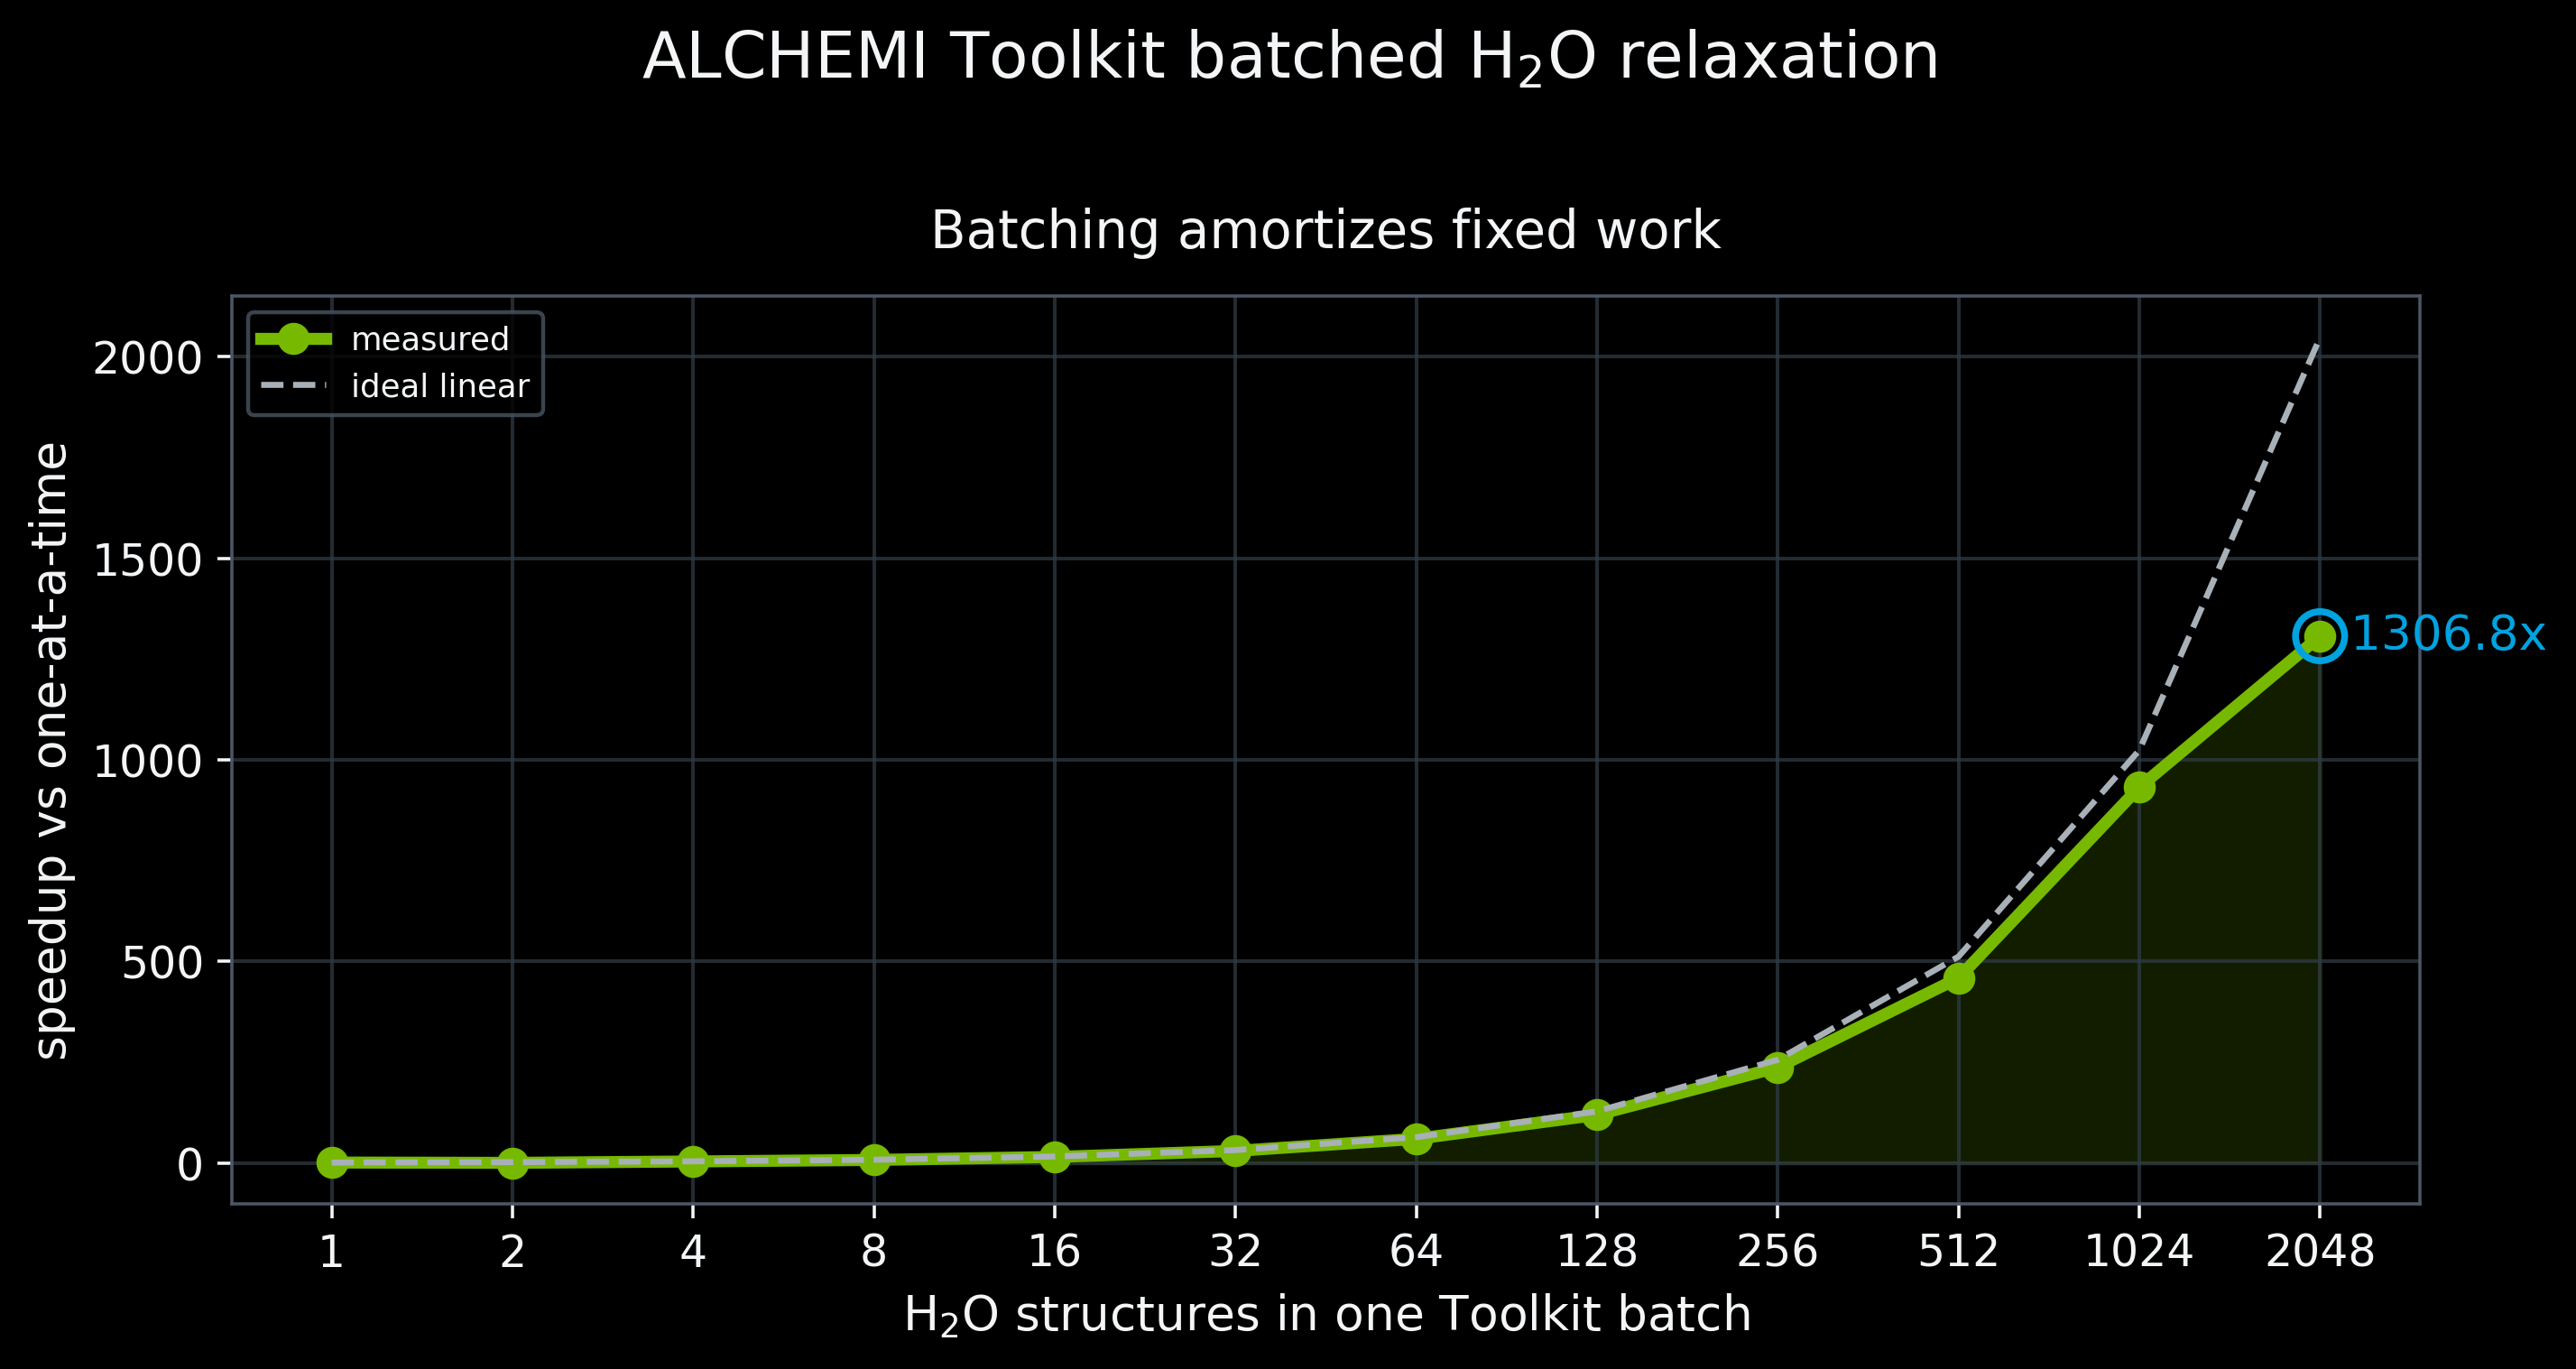

Saved: outputs/live_runs/20260518-014249/tutorial/h2o_speedup_full/figures/h2o_toolkit_batch_speedup.png
E(H2O, gas) = -13.7857 eV


,batch_size,wall_time_s,structures_per_s,energy_mean_eV,energy_std_eV,one_at_a_time_s,speedup_vs_single
0,1,0.232925,4.293232,-13.785692,0.000000e+00,0.232925,1.000000
1,2,1.987537,1.006270,-13.785692,0.000000e+00,0.465850,0.234385
2,4,0.249336,16.042578,-13.785311,0.000000e+00,0.931699,3.736714
3,8,0.249418,32.074608,-13.785086,0.000000e+00,1.863398,7.470970
4,16,0.249190,64.208037,-13.785086,0.000000e+00,3.726796,14.955641
5,32,0.249906,128.047992,-13.785059,0.000000e+00,7.453592,29.825547
6,64,0.249215,256.805873,-13.784967,0.000000e+00,14.907184,59.816445
7,128,0.249920,512.163050,-13.784071,0.000000e+00,29.814369,119.295453
8,256,0.251377,1018.390959,-13.784286,2.639441e-07,59.628737,237.208464
9,512,0.259929,1969.771011,-13.785078,0.000000e+00,119.257474,458.808430


In [27]:
# Step 6: run the H2O batches, compute speedup, and display the figure.
# One unreported warm-up pass keeps the plot focused on batching rather
# than first-call CUDA/kernel setup.
warmup_result = run_h2o_batch(1)
h2o_speedup_rows = []
progress = make_notebook_progress(
    title="Toolkit batch sweep",
    total=len(H2O_BATCH_SIZES),
    unit="batch sizes",
    message="warmup complete; starting H2O batches",
    average_label="s/batch run",
    width_px=560,
)
for index, size in enumerate(H2O_BATCH_SIZES, start=1):
    progress.update(done=index - 1, message=f"running batch size {size}")
    h2o_speedup_rows.append(run_h2o_batch(size))
    progress.update(done=index, message=f"finished batch size {size}")

h2o_speedup_df = pd.DataFrame(h2o_speedup_rows)
os.makedirs(os.path.dirname(H2O_SPEEDUP_CACHE), exist_ok=True)
h2o_speedup_df.to_csv(H2O_SPEEDUP_CACHE, index=False)

single_time = float(h2o_speedup_df.loc[h2o_speedup_df["batch_size"] == 1, "wall_time_s"].iloc[0])
h2o_speedup_df["one_at_a_time_s"] = single_time * h2o_speedup_df["batch_size"]
h2o_speedup_df["speedup_vs_single"] = h2o_speedup_df["one_at_a_time_s"] / h2o_speedup_df["wall_time_s"]
E_H2O_gas = float(h2o_speedup_df.loc[h2o_speedup_df["batch_size"] == 1, "energy_mean_eV"].iloc[0])
results = h2o_speedup_df.to_dict("records")

H2O_SPEEDUP_FIGURE = plot_h2o_batch_speedup(
    speedup_df=h2o_speedup_df,
    examples=[],
    output_path=H2O_SPEEDUP_FIGURE,
)
display_inline(H2O_SPEEDUP_FIGURE)
print(f"Saved: {H2O_SPEEDUP_FIGURE}")
print(f"E(H2O, gas) = {E_H2O_gas:.4f} eV")
h2o_speedup_df


### Adsorption batch calibration

The H<sub>2</sub>O figure isolates the batching idea. Adsorption batches are heavier: each item includes a slab, an adsorbate, periodic boundaries, frozen atoms, and neighbor lists. Before a longer search, it is useful to measure the throughput knee for the actual chemistry.

Here we run a short H<sub>2</sub>O/TiO<sub>2</sub>(110) relaxation pool and compare two MACE choices:

- `medium-mpa-0`: a general MACE-MPA model for broad materials chemistry. It is a useful default comparison point, but it is not the same as an OC20 surface-adsorption head.
- `MACE-MH-1 / OC20 surface head`: the `mh-1` checkpoint is a multi-head MACE foundation model; `oc20_usemppbe` selects its OC20/PBE head for surface catalysis and adsorbate systems.

The point is practical model selection. A surface-specialized model is not automatically too expensive for a batched workflow; on this calibration pool, the OC20 surface head is close enough in throughput that accuracy and chemical fit become the deciding criteria. We still measure memory and structures/s because the best batch size depends on the model, system size, and GPU. The recommended batch is the smallest measured batch near the best structures/s rate while staying under a realistic VRAM headroom rule.


In [28]:
# Adsorption calibration setup: short relaxations on a representative oxide-surface pool.
ADSORPTION_CALIBRATION_HOST = "TiO2(110)"
ADSORPTION_CALIBRATION_ADSORBATE = "H2O"
ADSORPTION_CALIBRATION_TAG = "h2o_tio2_110"
ADSORPTION_CALIBRATION_BATCH_SIZES_BY_SCOPE = {
    "short": [4, 8, 12],
    "full": [4, 8, 12, 16, 24],
}
ADSORPTION_CALIBRATION_BATCH_SIZES = ADSORPTION_CALIBRATION_BATCH_SIZES_BY_SCOPE[RUN_SCOPE]
ADSORPTION_CALIBRATION_STEPS = 40
ADSORPTION_CALIBRATION_DT = 0.01  # short FIRE2 step size used only for this batch-size calibration
ADSORPTION_CALIBRATION_MEMORY_FRACTION = 0.80
ADSORPTION_CALIBRATION_MODELS = [
    {"label": "MACE-MPA-0 medium", "checkpoint": "medium-mpa-0", "head": None},
    {"label": "MACE-MH-1 / OC20 surface head", "checkpoint": "mh-1", "head": "oc20_usemppbe"},
]
ADSORPTION_CALIBRATION_ROOT = os.path.join(
    TUTORIAL_OUTPUT_DIR, f"adsorption_batch_calibration_{ADSORPTION_CALIBRATION_TAG}_{RUN_SCOPE}"
)
ADSORPTION_CALIBRATION_FULL_ROOT = os.path.join(
    TUTORIAL_OUTPUT_DIR, f"adsorption_batch_calibration_{ADSORPTION_CALIBRATION_TAG}_full"
)
ADSORPTION_CALIBRATION_CACHE = os.path.join(
    ADSORPTION_CALIBRATION_ROOT, "tables", "adsorption_batch_calibration.csv"
)
ADSORPTION_CALIBRATION_FULL_CACHE = os.path.join(
    ADSORPTION_CALIBRATION_FULL_ROOT, "tables", "adsorption_batch_calibration.csv"
)
ADSORPTION_CALIBRATION_FIGURE = os.path.join(
    ADSORPTION_CALIBRATION_ROOT, "figures", "adsorption_batch_calibration.png"
)
ADSORPTION_CALIBRATION_FULL_FIGURE = os.path.join(
    ADSORPTION_CALIBRATION_FULL_ROOT, "figures", "adsorption_batch_calibration.png"
)

print(f"Calibration chemistry      : {ADSORPTION_CALIBRATION_ADSORBATE} on {ADSORPTION_CALIBRATION_HOST}")
print(f"Short relaxation cap       : {ADSORPTION_CALIBRATION_STEPS} optimizer steps")
print(f"Batch sizes to test        : {ADSORPTION_CALIBRATION_BATCH_SIZES}")
print("Models to test             : " + ", ".join(spec["label"] for spec in ADSORPTION_CALIBRATION_MODELS))


Calibration chemistry      : H2O on TiO2(110)
Short relaxation cap       : 40 optimizer steps
Batch sizes to test        : [4, 8, 12, 16, 24]
Models to test             : MACE-MPA-0 medium, MACE-MH-1 / OC20 surface head


Calibration pool: 27 starting structures; larger batches cycle through this pool to measure GPU throughput.


HTML(value='\n        <style>\n          html, body, .jp-RenderedHTMLCommon, .output_html {\n            backg…

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument


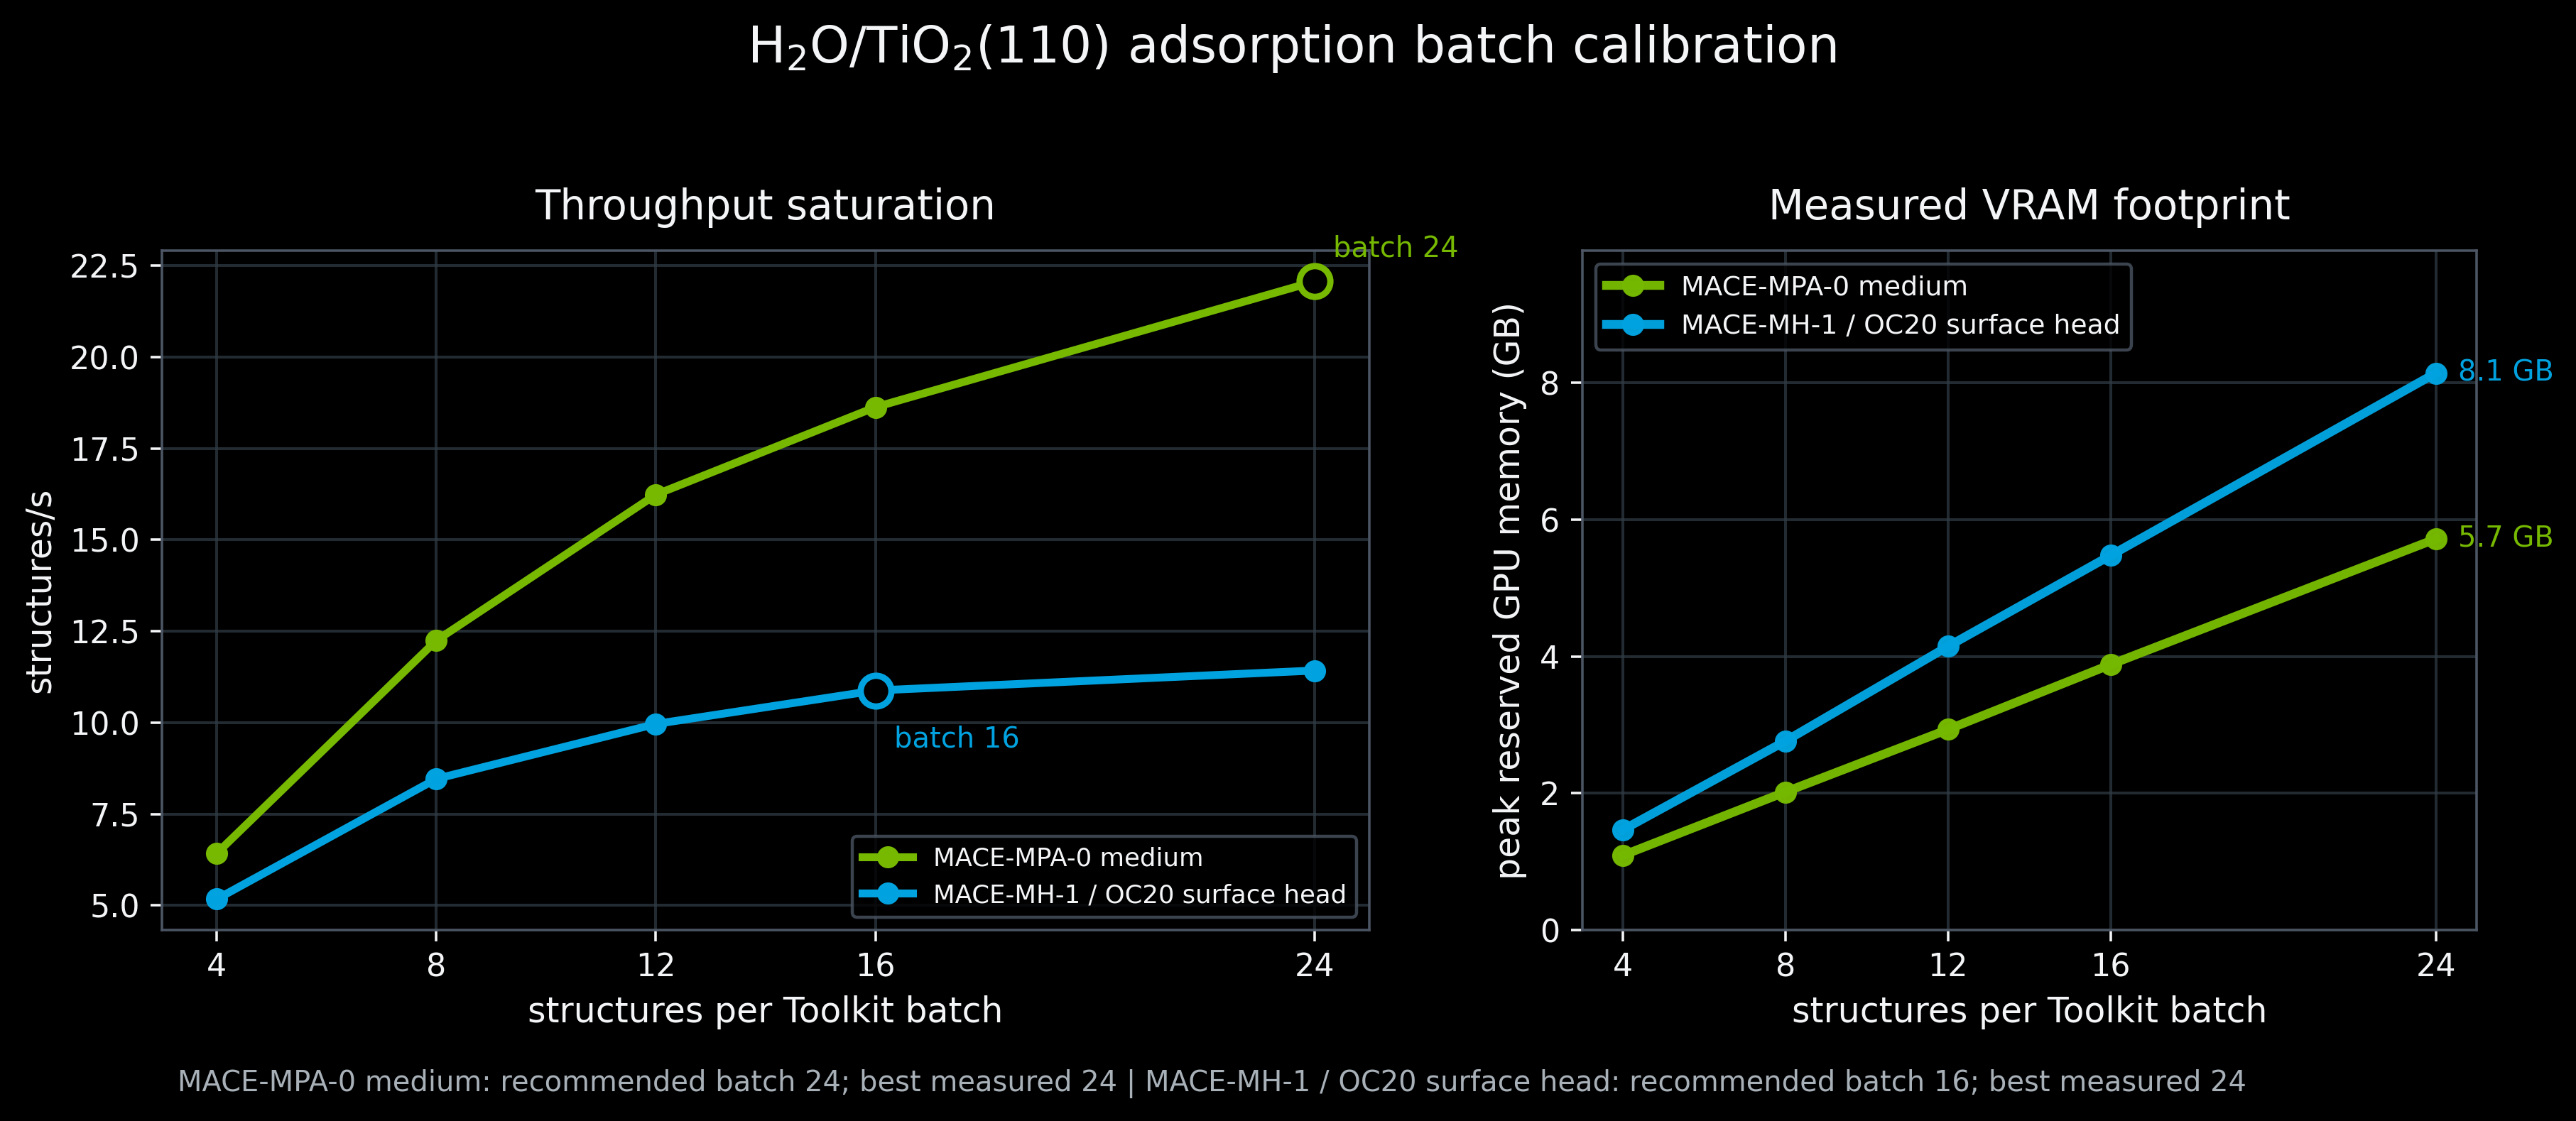

Saved: outputs/live_runs/20260518-014249/tutorial/adsorption_batch_calibration_h2o_tio2_110_full/figures/adsorption_batch_calibration.png
Recommended adsorption batch sizes:
  MACE-MPA-0 medium: batch 24 (22.06 structures/s, 1655 atoms/s, 5.72 GB reserved footprint, 5.45 GB observed free-VRAM drop)
  MACE-MH-1 / OC20 surface head: batch 16 (10.88 structures/s, 816 atoms/s, 5.48 GB reserved footprint, 5.21 GB observed free-VRAM drop)
Full timing rows are saved to CSV; the figure shows throughput saturation and measured VRAM footprint.
Detailed timing rows: outputs/live_runs/20260518-014249/tutorial/adsorption_batch_calibration_h2o_tio2_110_full/tables/adsorption_batch_calibration.csv


In [41]:
# Run or load the adsorption batch-size calibration, then show the performance figure.
from IPython.display import Markdown, display

(
    adsorption_calibration_df,
    adsorption_calibration_summary,
    adsorption_calibration_cache_source,
) = load_or_run_adsorption_batch_calibration(
    use_precomputed=USE_SAVED_TUTORIAL_RESULTS,
    run_scope=RUN_SCOPE,
    batch_sizes=ADSORPTION_CALIBRATION_BATCH_SIZES,
    cache_path=ADSORPTION_CALIBRATION_CACHE,
    full_cache_path=ADSORPTION_CALIBRATION_FULL_CACHE,
    tutorial_relpath=tutorial_relpath,
    host_name=ADSORPTION_CALIBRATION_HOST,
    adsorbate_name=ADSORPTION_CALIBRATION_ADSORBATE,
    model_specs=ADSORPTION_CALIBRATION_MODELS,
    output_dir=TUTORIAL_OUTPUT_DIR,
    toolkit_device=("cuda" if TOOLKIT_DEVICE == "auto" else TOOLKIT_DEVICE),
    toolkit_dtype=TOOLKIT_DTYPE,
    toolkit_dt=ADSORPTION_CALIBRATION_DT,
    n_steps=ADSORPTION_CALIBRATION_STEPS,
    memory_fraction=ADSORPTION_CALIBRATION_MEMORY_FRACTION,
    compile_model=TOOLKIT_COMPILE_MODEL,
    enable_cueq=TOOLKIT_ENABLE_CUEQ,
    progress_factory=make_notebook_progress,
    display_fn=display,
    markdown_cls=Markdown,
)

calibration_figure_path = ADSORPTION_CALIBRATION_FIGURE
if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS:
    calibration_figure_path = os.path.join(
        PLOTS_DIR,
        f"adsorption_batch_calibration_{ADSORPTION_CALIBRATION_TAG}_{RUN_SCOPE}.png",
    )

ADSORPTION_CALIBRATION_FIGURE = plot_adsorption_batch_calibration(
    adsorption_calibration_df,
    output_path=calibration_figure_path,
    title="H$_2$O/TiO$_2$(110) adsorption batch calibration",
)
display_inline(ADSORPTION_CALIBRATION_FIGURE)
print(f"Saved: {tutorial_relpath(ADSORPTION_CALIBRATION_FIGURE)}")

display_adsorption_batch_calibration_results(
    adsorption_calibration_df,
    adsorption_calibration_summary,
    display_fn=display,
    markdown_cls=Markdown,
)
print(f"Detailed timing rows: {tutorial_relpath(adsorption_calibration_cache_source)}")


In [30]:
# First visual check: one H2O/TiO2(110) starting configuration from the batch pool.
# The widget is intentionally before the validation block: readers should see the
# surface/adsorbate object before reading energy and RMSD tables.
from helpers import build_adsorption_calibration_pool

h2o_tio2_preview_pool = build_adsorption_calibration_pool(
    host_name=ADSORPTION_CALIBRATION_HOST,
    adsorbate_name=ADSORPTION_CALIBRATION_ADSORBATE,
    rotations_deg=(0.0,),
    heights_A=(2.2,),
)
h2o_tio2_preview = h2o_tio2_preview_pool[0]
print(f"Preview structure: {h2o_tio2_preview.label} | atoms={len(h2o_tio2_preview.atoms)}")
display_widgets_row(
    [("H2O on TiO2(110) starting geometry", h2o_tio2_preview.atoms)],
    width="360px",
    height="300px",
    show_cell=True,
)


Preview structure: H2O_TiO2(110)_ti-top_O-down_rot0_h2.2 | atoms=75


### Before screening: can this model handle adsorption?

The H<sub>2</sub>O/TiO<sub>2</sub>(110) example shows what batching changes computationally: a GPU can relax many molecule-on-surface structures at once instead of repeating the same small calculation one structure at a time. The next question is a bit more scientific:

> **Can the model give useful answers for molecule-on-surface chemistry?**

Before we use the workflow to screen new adsorption configurations, we compare against released OC20Dense DFT data. This gives the tutorial a reference point: the starting structures, relaxed DFT geometries, and adsorption-energy targets come from a published surface-chemistry benchmark, while the calculations below are rerun with the Toolkit/MACE. 

We use two compact checks:

- **Relaxation check:** replay three released OC20Dense adsorption trajectories from their published starting frames. For one H<sub>2</sub>O, one NH<sub>3</sub>, and one N<sub>2</sub> case, the notebook writes the MACE relaxation trajectory and compares its endpoint with the released DFT trajectory endpoint: final adsorption energy, adsorbate geometry, and RMSD.
- **Ranking check:** take 92 DFT-relaxed NH<sub>3</sub> configurations for the same surface system, evaluate them in one batched single-point calculation, and ask whether MACE preserves the same relative adsorption landscape. Energies are shifted to the DFT rank-1 geometry, so the comparison focuses on ranking rather than an arbitrary absolute zero.

H<sub>2</sub>O, NH<sub>3</sub>, and N<sub>2</sub> are used here because their neutral gas references are unambiguous. D3 corrections are available in Toolkit workflows, but they stay off in this validation because the OC20Dense reference targets used here follow the non-D3 OC20 convention.

`VALIDATION_RESULT_SOURCE` controls this section. The default is `"compute"`; set it to `"saved"` in the control panel when you want to inspect saved validation tables without rerunning the benchmark.


In [31]:
# Validation settings: choose the examples, ranks, and model used for this checkpoint.
from IPython.display import Markdown, display

VALIDATION_TOOLKIT_CHECKPOINT = "mh-1"
VALIDATION_TOOLKIT_HEAD = "oc20_usemppbe"

TRAJECTORY_VALIDATION_SELECTION = [
    {"system_id": "3_2070_48", "config_id": "rand64", "sid": 14966, "adsorbate": "H2O", "dft_rank": 1},
    {"system_id": "72_7104_115", "config_id": "rand27", "sid": 3469, "adsorbate": "NH3", "dft_rank": 1},
    {"system_id": "69_1615_2", "config_id": "rand2", "sid": 23355, "adsorbate": "N2", "dft_rank": 1},
]

NH3_RANKING_SYSTEM = "72_7104_115"
NH3_RANKING_PREVIEW_RANKS = [1, 4, 16, 92]
SHOW_ALL_NH3_RANKING = False

VALIDATION_SINGLE_POINT_BATCH_SIZE = 12
VALIDATION_TOOLKIT_N_STEPS = 200
VALIDATION_TOOLKIT_FMAX = 0.05  # eV/A force threshold for validation relaxations

validation_context = make_oc20dense_validation_context(
    tutorial_root=TUTORIAL_ROOT,
    accuracy_output_dir=ACCURACY_OUTPUT_DIR,
    result_source=VALIDATION_RESULT_SOURCE,
    checkpoint=VALIDATION_TOOLKIT_CHECKPOINT,
    head=VALIDATION_TOOLKIT_HEAD,
    trajectory_selection=TRAJECTORY_VALIDATION_SELECTION,
    nh3_system=NH3_RANKING_SYSTEM,
    preview_ranks=NH3_RANKING_PREVIEW_RANKS,
    show_all_nh3_ranking=SHOW_ALL_NH3_RANKING,
    single_point_batch_size=VALIDATION_SINGLE_POINT_BATCH_SIZE,
    n_steps=VALIDATION_TOOLKIT_N_STEPS,
    fmax=VALIDATION_TOOLKIT_FMAX,
)

VALIDATION_MODEL_LABEL = validation_context.model_label
OC20DENSE_SOURCE_ROOT = validation_context.oc20dense_data_root
TRAJECTORY_VALIDATION_ROOT = validation_context.trajectory_root
NH3_RANKING_ROOT = validation_context.nh3_ranking_root

validation_choices_df = validation_context_table(validation_context, relpath_fn=tutorial_relpath)
display(validation_choices_df)


,choice,value
0,result source,compute
1,model,mh-1 (head=oc20_usemppbe)
2,relaxation check,"3 OC20Dense starts (H2O, NH3, N2), Toolkit bat..."
3,NH3 ranking,"system 72_7104_115, 92 DFT-relaxed geometries,..."
4,relaxation stop,"200 step cap, fmax <= 0.05 eV/A"
5,reference data,data/reference/oc20dense
6,trajectory output,outputs/live_runs/20260518-014249/accuracy/oc2...
7,NH3 ranking output,outputs/live_runs/20260518-014249/accuracy/oc2...


### Run the validation

With `VALIDATION_RESULT_SOURCE = "compute"`, the next cell reruns the compact OC20Dense checkpoint directly from the Toolkit/Python workflow. With `"saved"`, it does not recompute anything; it only shows which saved result folders will feed the display cells.


In [35]:
# Compute the validation checkpoint, or show the saved sources selected above.
validation_runtime_df = run_or_load_oc20dense_validation(
    validation_context,
    progress_factory=make_notebook_progress,
    display_fn=None,
    relpath_fn=tutorial_relpath,
)

display(Markdown(
    "Elapsed times below are notebook-side work: Toolkit recomputation plus lookup "
    "and consistency checks against released DFT reference records. No DFT is run here."
))
display(validation_runtime_df)


HTML(value='\n        <style>\n          html, body, .jp-RenderedHTMLCommon, .output_html {\n            backg…

Elapsed times below are notebook-side work: Toolkit recomputation plus lookup and consistency checks against released DFT reference records. No DFT is run here.

,validation check,timed action,elapsed_min,log
0,relaxation check,Toolkit relaxation batch,0.118204,outputs/live_runs/20260518-014249/accuracy/rep...
1,relaxation check,Released DFT reference lookup and RMSD check,0.006893,outputs/live_runs/20260518-014249/accuracy/rep...
2,relaxation check,Toolkit adsorption-energy recomputation,0.112861,outputs/live_runs/20260518-014249/accuracy/rep...
3,NH3 fixed-geometry ranking,Released DFT ranking lookup for all 92 NH3 str...,0.248574,outputs/live_runs/20260518-014249/accuracy/rep...
4,NH3 fixed-geometry ranking,Toolkit single-point scoring on 92 DFT-final g...,0.176066,outputs/live_runs/20260518-014249/accuracy/rep...


In [51]:
# Relaxation check: compare MACE-relaxed endpoints with released DFT trajectories.
trajectory_validation = show_trajectory_validation_results(
    validation_context,
    display_fn=display,
    markdown_cls=Markdown,
)
trajectory_per_config = trajectory_validation["trajectory_per_config"]
trajectory_dft_reference = trajectory_validation["trajectory_dft_reference"]
trajectory_mace_results = trajectory_validation["trajectory_mace_results"]
trajectory_mace_refs = trajectory_validation["trajectory_mace_refs"]
trajectory_relaxation_errors = trajectory_validation["trajectory_relaxation_errors"]
max_trajectory_dft_target_delta_eV = trajectory_validation["max_trajectory_dft_target_delta_eV"]

trajectory_widget_paths = show_trajectory_validation_widget_grid(
    validation_context,
    trajectory_validation,
    display_fn=display,
    markdown_cls=Markdown,
    trajectory_grid_fn=display_trajectory_widgets_grid,
    width="520px",
    height="260px",
    show_cell=False,
)


#### Relaxation check: Toolkit trajectories against OC20Dense DFT

,adsorbate,system_id,config_id,DFT Eads (eV),MACE relaxed Eads (eV),Eads error (eV),"all-atom RMSD, MIC (A)"
0,*OH2,3_2070_48,rand64,-0.542908,-0.557576,-0.014668,0.051686
1,*N2,69_1615_2,rand2,-0.081494,-0.009438,0.072057,0.170038
2,*NH3,72_7104_115,rand27,-2.049714,-1.046410,1.003304,0.342235


RMSD is reported for all atoms using the exact OC20Dense atom order and the minimum-image convention for periodic boundaries.

Max DFT trajectory-target difference: `0.00e+00 eV`. The largest relaxed-endpoint miss in this compact slice is `*NH3`: Eads error `1.003 eV`, all-atom RMSD `0.342 A`.

#### Toolkit/MACE reference terms used for relaxed Eads

These clean-surface and gas terms are recomputed with `mh-1 (head=oc20_usemppbe)` so the MACE-relaxed adsorption energy uses one consistent model. The DFT comparison column above comes from the released OC20Dense adsorption-energy target.

,system_id,isolated gas molecule,Toolkit/MACE gas energy (eV),gas_converged,gas steps,Toolkit/MACE clean-surface energy (eV),surface fmax after Toolkit/MACE relaxation (eV/A)
0,3_2070_48,H2O,-14.101893,True,23,-32.549141,0.049591
1,72_7104_115,NH3,-19.305305,True,28,-323.020874,0.048292
2,69_1615_2,N2,-16.063347,True,13,-117.903534,0.049961


#### DFT and MACE trajectory widgets

In [47]:
# Fixed-geometry ranking: score all 92 NH3 DFT-relaxed final geometries in batches.
nh3_ranking_results = show_nh3_ranking_results(
    validation_context,
    display_fn=display,
    markdown_cls=Markdown,
)
ranking_dft_reference = nh3_ranking_results["ranking_dft_reference"]
ranking_dft_final_sp = nh3_ranking_results["ranking_dft_final_sp"]
nh3_ranking_all = nh3_ranking_results["nh3_ranking_all"]
rank1_summary = nh3_ranking_results["rank1_summary"]
max_ranking_dft_target_delta_eV = nh3_ranking_results["max_ranking_dft_target_delta_eV"]
max_ranking_start_adsorbate_rmsd_A = nh3_ranking_results["max_ranking_start_adsorbate_rmsd_A"]


#### Fixed-geometry NH<sub>3</sub> ranking: 92 DFT-relaxed structures

DFT rank,config_id,sid,DFT gap from DFT-best (eV),MACE gap from DFT-best geometry (eV),"relative-energy error, MACE - DFT (eV)",MACE rank
1,rand27,3469,0.000000,0.000000,0.000000,1
2,rand13,13996,0.011468,0.014862,0.003394,3
3,heur8,56261,0.012765,0.013794,0.001029,2
4,rand16,40768,0.021999,0.029785,0.007787,4
5,rand12,22015,0.154065,0.214569,0.060504,21
6,heur36,72835,0.155021,0.197784,0.042763,11
7,rand6,9067,0.155246,0.195129,0.039883,10
8,rand5,45787,0.155373,0.199554,0.044181,12
9,heur1,197,0.155551,0.199677,0.044126,13
10,heur17,79002,0.156010,0.200928,0.044918,14


Showing the first 10 and last 10 configurations by released DFT adsorption-energy rank. Set `SHOW_ALL_NH3_RANKING = True` in the validation settings cell to display all 92 rows.

Across all 92 fixed geometries, the DFT-best anchored relative-energy error is RMSE `0.0735 eV`, MAE `0.0617 eV`, bias `-0.0486 eV`, and Spearman rank correlation `0.944`.

The ranking metric compares relative gaps from the same DFT-best geometry: `E(row) - E(DFT-best)` for DFT and for MACE. Because all rows share the same surface and adsorbate, constant gas/surface offsets cancel. The relative-energy error is `MACE gap - DFT gap`.

In [48]:
# Visual inspection: show selected NH3 ranks, then scan all 92 DFT-final geometries without paging controls.
nh3_highlight_pairwise_rmsd = show_nh3_geometry_widgets(
    validation_context,
    nh3_ranking_results,
    display_fn=display,
    markdown_cls=Markdown,
    widgets_row_fn=display_widgets_row,
)

nh3_all_geometry_widget_paths = show_nh3_all_geometry_grid(
    validation_context,
    nh3_ranking_results,
    display_fn=display,
    markdown_cls=Markdown,
    paged_grid_fn=display_paged_widgets_grid,
    width="180px",
    height="160px",
    columns=4,
    page_size=12,
    show_cell=False,
)


#### Highlighted NH<sub>3</sub> geometries

#### Geometry spread among highlighted NH<sub>3</sub> ranks

,rank pair,config pair,"adsorbate COM distance, MIC (A)",internal adsorbate RMSD (A)
0,1 vs 4,rand27 vs rand16,3.465407,4.740306
1,1 vs 16,rand27 vs heur23,0.981217,1.191344
2,1 vs 92,rand27 vs rand60,3.281312,1.312082
3,4 vs 16,rand16 vs heur23,4.302342,5.498181
4,4 vs 92,rand16 vs rand60,6.343156,5.745867
5,16 vs 92,heur23 vs rand60,3.174517,1.267340


The pairwise table uses DFT-relaxed final structures and is reported in A. COM distances use the minimum-image convention; internal RMSD compares the adsorbate after subtracting its COM. This is a visual-diversity check, not a model-error metric.

#### NH<sub>3</sub> 92-configuration visual scan

In [120]:
# Model-cost trade-off observed for this validation slice.
validation_model_tradeoff = show_validation_model_tradeoff(
    display_fn=display,
    markdown_cls=Markdown,
)
model_cost_sp = validation_model_tradeoff["model_cost_sp"]
model_cost_relax = validation_model_tradeoff["model_cost_relax"]


#### Model choice is a cost/accuracy trade-off

,model,workload,batch size,wall time (s),energy evaluation (s),peak GPU alloc (GB),rank RMSE (eV),DFT rank selected by MACE
0,MACE-MPA-0 medium,92 NH3 fixed-geometry single-point energies,12,14.90,1.48,2.85,0.1780,3
1,MACE-MH-1 / OC20 surface head,92 NH3 fixed-geometry single-point energies,12,15.54,1.42,6.12,0.0716,1


,model,workload,batch size,wall time (s),relax time (s),peak GPU alloc (GB),converged,trajectory frames
0,MACE-MPA-0 medium,H2O/NH3/N2 relaxation check,3,10.79,5.11,0.57,3/3,198 each
1,MACE-MH-1 / OC20 surface head,H2O/NH3/N2 relaxation check,3,12.17,6.47,1.17,2/3,200 each


For this OC20Dense slice, the surface-specialized head gives the stronger ranking check while using more GPU memory. That is the point of measuring both accuracy and throughput before a larger adsorption search.

---

## Design the surface-screen panel

Now move from the small H<sub>2</sub>O batching example to adsorption chemistry. The point is not to hide the structure generation in a helper. The surface choices, Miller indices, molecular probes, and starting-geometry rules are the scientific object of the tutorial.

This panel is a compact mock of an early R&D screen:

- one **metal family**: Cu low-index terraces, where the Miller index changes the coordination of surface atoms;
- one **oxide family**: rutile TiO<sub>2</sub>, where different cuts expose different Ti/O motifs;
- one **nitride/ceramic family**: rocksalt TiN, including a stepped high-index cut.

For each surface, we test CO, H<sub>2</sub>O, NH<sub>3</sub>, and CH<sub>3</sub>OH. The search is deliberately controlled: three starting sites, two molecular orientations, one conservative height. That gives six starting geometries per adsorbate/surface pair and makes the batching question concrete without turning the notebook into a black box.


In [44]:
# Metal family: three Cu facets with distinct surface coordination.
# The display helper below only formats the plan table; the choices stay visible in this cell.
def slab_plan_table(specs):
    return pd.DataFrame([
        {
            "surface": spec.name,
            "class": spec.material_class,
            "Miller index": str(spec.miller_index),
            "facet model": spec.facet,
            "builder": spec.builder_name,
            "supercell": str(spec.default_supercell),
            "why included": spec.note,
        }
        for spec in specs
    ])


CU_SLAB_SPECS = [
    SurfaceScreenSlabSpec(
        name="Cu(111)", material_class="fcc metal", facet="close-packed terrace",
        miller_index=(1, 1, 1), builder_name="build_cu111_slab",
        builder=lambda: build_cu111_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(3, 3, 1)),
        default_supercell=(3, 3, 1),
        note="close-packed low-index Cu surface",
    ),
    SurfaceScreenSlabSpec(
        name="Cu(100)", material_class="fcc metal", facet="square terrace",
        miller_index=(1, 0, 0), builder_name="build_cu100_slab",
        builder=lambda: build_cu100_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(3, 3, 1)),
        default_supercell=(3, 3, 1),
        note="square low-index Cu surface",
    ),
    SurfaceScreenSlabSpec(
        name="Cu(110)", material_class="fcc metal", facet="open row surface",
        miller_index=(1, 1, 0), builder_name="build_cu110_slab",
        builder=lambda: build_cu110_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(3, 3, 1)),
        default_supercell=(3, 3, 1),
        note="more open low-index Cu surface",
    ),
]
CU_HOSTS = {spec.name: spec.builder() for spec in CU_SLAB_SPECS}

display(slab_plan_table(CU_SLAB_SPECS))
display_widgets_row([(name, atoms) for name, atoms in CU_HOSTS.items()], width="230px", height="210px")


,surface,class,Miller index,facet model,builder,supercell,why included
0,Cu(111),fcc metal,"(1, 1, 1)",close-packed terrace,build_cu111_slab,"(3, 3, 1)",close-packed low-index Cu surface
1,Cu(100),fcc metal,"(1, 0, 0)",square terrace,build_cu100_slab,"(3, 3, 1)",square low-index Cu surface
2,Cu(110),fcc metal,"(1, 1, 0)",open row surface,build_cu110_slab,"(3, 3, 1)",more open low-index Cu surface


### Add rutile TiO<sub>2</sub> facets

The oxide block keeps the composition fixed and changes the surface cut. That is the point of the Miller-index axis: TiO<sub>2</sub>(110), TiO<sub>2</sub>(100), and TiO<sub>2</sub>(101) expose different Ti/O arrangements, so the adsorption search is not just repeating the same slab three times.


In [183]:
# Oxide family: three rutile TiO2 cuts with different exposed Ti/O motifs.
TIO2_SLAB_SPECS = [
    SurfaceScreenSlabSpec(
        name="TiO2(110)", material_class="oxide", facet="rutile bridge-row surface",
        miller_index=(1, 1, 0), builder_name="build_tio2_110_slab",
        builder=lambda: build_tio2_110_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(2, 2, 1)),
        default_supercell=(2, 2, 1),
        note="canonical rutile surface with rows of under-coordinated Ti/O sites",
    ),
    SurfaceScreenSlabSpec(
        name="TiO2(100)", material_class="oxide", facet="rutile side surface",
        miller_index=(1, 0, 0), builder_name="build_tio2_100_slab",
        builder=lambda: build_tio2_100_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(2, 2, 1)),
        default_supercell=(2, 2, 1),
        note="second low-index rutile cut",
    ),
    SurfaceScreenSlabSpec(
        name="TiO2(101)", material_class="oxide", facet="rutile oblique surface",
        miller_index=(1, 0, 1), builder_name="build_tio2_101_slab",
        builder=lambda: build_tio2_101_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(2, 2, 1)),
        default_supercell=(2, 2, 1),
        note="oblique rutile cut; useful contrast to (110) and (100)",
    ),
]
TIO2_HOSTS = {spec.name: spec.builder() for spec in TIO2_SLAB_SPECS}

display(slab_plan_table(TIO2_SLAB_SPECS))
display_widgets_row([(name, atoms) for name, atoms in TIO2_HOSTS.items()], width="230px", height="210px")


,surface,class,Miller index,facet model,builder,supercell,why included
0,TiO2(110),oxide,"(1, 1, 0)",rutile bridge-row surface,build_tio2_110_slab,"(2, 2, 1)",canonical rutile surface with rows of under-co...
1,TiO2(100),oxide,"(1, 0, 0)",rutile side surface,build_tio2_100_slab,"(2, 2, 1)",second low-index rutile cut
2,TiO2(101),oxide,"(1, 0, 1)",rutile oblique surface,build_tio2_101_slab,"(2, 2, 1)",oblique rutile cut; useful contrast to (110) a...


In [182]:
# Nitride/ceramic family: two nonpolar low-index TiN cuts and one stepped cut.
TIN_SLAB_SPECS = [
    SurfaceScreenSlabSpec(
        name="TiN(001)", material_class="nitride ceramic", facet="rocksalt nonpolar terrace",
        miller_index=(0, 0, 1), builder_name="build_tin_001_slab",
        builder=lambda: build_tin_001_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(2, 2, 1)),
        default_supercell=(2, 2, 1),
        note="nonpolar rocksalt TiN terrace",
    ),
    SurfaceScreenSlabSpec(
        name="TiN(110)", material_class="nitride ceramic", facet="rocksalt rectangular terrace",
        miller_index=(1, 1, 0), builder_name="build_tin_110_slab",
        builder=lambda: build_tin_110_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(2, 2, 1)),
        default_supercell=(2, 2, 1),
        note="second nonpolar TiN low-index cut",
    ),
    SurfaceScreenSlabSpec(
        name="TiN(210)", material_class="nitride ceramic", facet="rocksalt stepped surface",
        miller_index=(2, 1, 0), builder_name="build_tin_210_slab",
        builder=lambda: build_tin_210_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(2, 2, 1)),
        default_supercell=(2, 2, 1),
        note="stepped/high-index TiN cut; TiN(111) is avoided because it is polar",
    ),
]
TIN_HOSTS = {spec.name: spec.builder() for spec in TIN_SLAB_SPECS}

display(slab_plan_table(TIN_SLAB_SPECS))
display_widgets_row([(name, atoms) for name, atoms in TIN_HOSTS.items()], width="230px", height="210px")


,surface,class,Miller index,facet model,builder,supercell,why included
0,TiN(001),nitride ceramic,"(0, 0, 1)",rocksalt nonpolar terrace,build_tin_001_slab,"(2, 2, 1)",nonpolar rocksalt TiN terrace
1,TiN(110),nitride ceramic,"(1, 1, 0)",rocksalt rectangular terrace,build_tin_110_slab,"(2, 2, 1)",second nonpolar TiN low-index cut
2,TiN(210),nitride ceramic,"(2, 1, 0)",rocksalt stepped surface,build_tin_210_slab,"(2, 2, 1)",stepped/high-index TiN cut; TiN(111) is avoide...


In [102]:
# Assemble the panel after each family has been defined and inspected.
SURFACE_SCREEN_SLABS = CU_SLAB_SPECS + TIO2_SLAB_SPECS + TIN_SLAB_SPECS
HOSTS = {**CU_HOSTS, **TIO2_HOSTS, **TIN_HOSTS}
HOST_NAMES = [spec.name for spec in SURFACE_SCREEN_SLABS]
HOST_COMPOSITIONS = {spec.name: spec.name.split("(")[0] for spec in SURFACE_SCREEN_SLABS}
HOST_MILLER_INDICES = {spec.name: spec.miller_index for spec in SURFACE_SCREEN_SLABS}
HOST_RELAXED = {name: atoms.copy() for name, atoms in HOSTS.items()}
HOST_RELAXED_ENERGIES = {}

host_plan_df = pd.DataFrame([
    {
        "surface": spec.name,
        "class": spec.material_class,
        "Miller index": str(spec.miller_index),
        "facet model": spec.facet,
        "atoms": len(HOSTS[spec.name]),
        "note": spec.note,
    }
    for spec in SURFACE_SCREEN_SLABS
])
display(host_plan_df)

# Sanity check: the planned panel size is explicit before any Toolkit call.
SURFACE_SCREEN_COUNTS = surface_screen_expected_counts(
    n_slabs=len(SURFACE_SCREEN_SLABS),
    n_adsorbates=4,
    starts_per_pair=6,
)
for key, value in SURFACE_SCREEN_COUNTS.items():
    print(f"{key:<28}: {value}")


,surface,class,Miller index,facet model,atoms,note
0,Cu(111),fcc metal,"(1, 1, 1)",close-packed terrace,36,close-packed low-index Cu surface
1,Cu(100),fcc metal,"(1, 0, 0)",square terrace,36,square low-index Cu surface
2,Cu(110),fcc metal,"(1, 1, 0)",open row surface,36,more open low-index Cu surface
3,TiO2(110),oxide,"(1, 1, 0)",rutile bridge-row surface,72,canonical rutile surface with rows of under-co...
4,TiO2(100),oxide,"(1, 0, 0)",rutile side surface,48,second low-index rutile cut
5,TiO2(101),oxide,"(1, 0, 1)",rutile oblique surface,96,oblique rutile cut; useful contrast to (110) a...
6,TiN(001),nitride ceramic,"(0, 0, 1)",rocksalt nonpolar terrace,32,nonpolar rocksalt TiN terrace
7,TiN(110),nitride ceramic,"(1, 1, 0)",rocksalt rectangular terrace,48,second nonpolar TiN low-index cut
8,TiN(210),nitride ceramic,"(2, 1, 0)",rocksalt stepped surface,96,stepped/high-index TiN cut; TiN(111) is avoide...


slabs                       : 9
adsorbates                  : 4
adsorbate_surface_pairs     : 36
starts_per_pair             : 6
adsorption_relaxations      : 216
clean_slab_relaxations      : 9
gas_reference_relaxations   : 4
core_relaxations            : 229


### Inspect the surface models

The surfaces are not names in a table; they are actual periodic slabs. Before adding molecules, inspect the clean slabs and check atom counts, cell sizes, exposed species, and vacuum. This is where a domain expert can catch an unreasonable termination or a surface that needs a different model before any GPU time is spent.


In [ ]:
# Visual check: inspect all nine clean starting slabs before adding adsorbates.
display_widgets_row(
    [(name, atoms) for name, atoms in HOSTS.items()],
    width="230px", height="210px",
)


## Choose molecular probes

The adsorbates are small, closed-shell probes that appear in many real surface-chemistry workflows. They are not claimed as a complete application study. They give a compact way to exercise different bonding motifs: carbonyl binding, water adsorption, ammonia donation, and alcohol adsorption.


In [103]:
# Visible adsorbate definition: two starting orientations per molecule.
SURFACE_SCREEN_ADSORBATES = [
    SurfaceScreenAdsorbateSpec("CO", ("C-down", "O-down"), "CO binding and catalysis probe", "linear molecule with two contact atoms"),
    SurfaceScreenAdsorbateSpec("H2O", ("O-down", "H-down"), "water adsorption and hydrophilicity", "closed-shell water adsorption example"),
    SurfaceScreenAdsorbateSpec("NH3", ("N-down", "H-down"), "ammonia binding and nitrogen chemistry", "lone-pair donor with H-down decoys"),
    SurfaceScreenAdsorbateSpec("CH3OH", ("O-down", "methyl-down"), "alcohol adsorption and separations proxy", "larger polar molecule with orientation sensitivity"),
]
ADSORBATES = [spec.name for spec in SURFACE_SCREEN_ADSORBATES]
ADSORBATE_ORIENTATIONS_FOR_SCREEN = {spec.name: list(spec.orientations) for spec in SURFACE_SCREEN_ADSORBATES}
ADSORBATE_HINTS = {spec.name: spec.application_hint for spec in SURFACE_SCREEN_ADSORBATES}
ADSORBATE_BUILDERS = {"CO": build_co, "H2O": build_h2o, "NH3": build_nh3, "CH3OH": build_methanol}

sample_adsorbates = []
for spec in SURFACE_SCREEN_ADSORBATES:
    for orient in spec.orientations:
        ads = ADSORBATE_BUILDERS[spec.name](orient)
        ads.set_cell([8, 8, 8]); ads.pbc = True; ads.center()
        sample_adsorbates.append((f"{spec.name} ({orient})", ads))

display_widgets_row(sample_adsorbates, width="220px", height="200px")


## Define the starting-geometry search

For each adsorbate/surface pair, the screen uses three site classes and two orientations. That is a small AdsorbML-style local search space: enough to make the starting-point assumption measurable, but still small enough to discuss in a live tutorial.

The starting height is 2.5 A. That is intentionally conservative for corrugated oxide and nitride surfaces: H-down and methyl-down decoy orientations should start above the surface, not buried inside it.


In [ ]:
# Site classes are chosen explicitly for each surface family.
# The site-finder mapping stays visible so the chemistry is not hidden in a helper.
SURFACE_SITES_BY_HOST = {
    "Cu(111)": ["top", "bridge", "fcc"],
    "Cu(100)": ["top", "bridge", "hollow"],
    "Cu(110)": ["top", "bridge", "hollow"],
    "TiO2(110)": ["ti-top", "o-top", "bridge"],
    "TiO2(100)": ["ti-top", "o-top", "bridge"],
    "TiO2(101)": ["ti-top", "o-top", "bridge"],
    "TiN(001)": ["ti-top", "n-top", "bridge"],
    "TiN(110)": ["ti-top", "n-top", "bridge"],
    "TiN(210)": ["ti-top", "n-top", "bridge"],
}
SURFACE_SITE_FINDERS = {
    "Cu(111)": find_fcc_sites,
    "Cu(100)": find_elemental_surface_sites,
    "Cu(110)": find_elemental_surface_sites,
    "TiO2(110)": lambda slab: find_oxide_sites(slab, cation_symbol="Ti", cation_site_name="ti-top"),
    "TiO2(100)": lambda slab: find_oxide_sites(slab, cation_symbol="Ti", cation_site_name="ti-top"),
    "TiO2(101)": lambda slab: find_oxide_sites(slab, cation_symbol="Ti", cation_site_name="ti-top"),
    "TiN(001)": lambda slab: find_binary_surface_sites(
        slab, cation_symbol="Ti", cation_site_name="ti-top", anion_symbol="N", anion_site_name="n-top"
    ),
    "TiN(110)": lambda slab: find_binary_surface_sites(
        slab, cation_symbol="Ti", cation_site_name="ti-top", anion_symbol="N", anion_site_name="n-top"
    ),
    "TiN(210)": lambda slab: find_binary_surface_sites(
        slab, cation_symbol="Ti", cation_site_name="ti-top", anion_symbol="N", anion_site_name="n-top"
    ),
}

# Site coordinates are computed after clean-slab relaxation/loading, so every
# starting geometry uses positions from the same slab geometry used for Eads.
SURFACE_SITE_CANDIDATES_BY_HOST = {}

ADSORPTION_START_HEIGHT_A = 2.5
ADSORPTION_ROTATIONS_DEG = (0.0,)
FROZEN_SLAB_FRACTION = 0.5
RELIABILITY_MAX_FORCE_EV_A = 0.2
DESORPTION_HEIGHT_A = 5.0
NOMINATED_SINGLE_START_BY_HOST = {
    host: sites[0]
    for host, sites in SURFACE_SITES_BY_HOST.items()
}

site_plan_df = pd.DataFrame([
    {
        "surface": host,
        "site classes": ", ".join(sites),
        "nominated single-start site": NOMINATED_SINGLE_START_BY_HOST[host],
    }
    for host, sites in SURFACE_SITES_BY_HOST.items()
])
orientation_plan_df = pd.DataFrame([
    {"adsorbate": spec.name, "orientations": ", ".join(spec.orientations), "why included": spec.note}
    for spec in SURFACE_SCREEN_ADSORBATES
])

display(site_plan_df)
display(orientation_plan_df)
print(f"Starting height: {ADSORPTION_START_HEIGHT_A} A; rotations: {ADSORPTION_ROTATIONS_DEG}; frozen slab fraction: {FROZEN_SLAB_FRACTION}")
print(f"Reliability filter: converged, adsorbed, max force <= {RELIABILITY_MAX_FORCE_EV_A} eV/A; desorbed if closest adsorbate atom is > {DESORPTION_HEIGHT_A} A above the slab.")


,surface,site classes,nominated single-start site
0,Cu(111),"top, bridge, fcc",top
1,Cu(100),"top, bridge, hollow",top
2,Cu(110),"top, bridge, hollow",top
3,TiO2(110),"ti-top, o-top, bridge",ti-top
4,TiO2(100),"ti-top, o-top, bridge",ti-top
5,TiO2(101),"ti-top, o-top, bridge",ti-top
6,TiN(001),"ti-top, n-top, bridge",ti-top
7,TiN(110),"ti-top, n-top, bridge",ti-top
8,TiN(210),"ti-top, n-top, bridge",ti-top


,adsorbate,orientations,why included
0,CO,"C-down, O-down",linear molecule with two contact atoms
1,H2O,"O-down, H-down",closed-shell water adsorption example
2,NH3,"N-down, H-down",lone-pair donor with H-down decoys
3,CH3OH,"O-down, methyl-down",larger polar molecule with orientation sensiti...


Starting height: 2.5 A; rotations: (0.0,); frozen slab fraction: 0.5
Reliability filter: converged, adsorbed, max force <= 0.2 eV/A; desorbed if closest adsorbate atom is > 5.0 A above the slab.


In [ ]:
# Starting-geometry construction: one relaxed slab, one molecule, and one chosen surface site.
def surface_normal_from_cell(slab: ase.Atoms) -> np.ndarray:
    normal = np.cross(slab.cell[0], slab.cell[1])
    return normal / np.linalg.norm(normal)


def place_adsorbate_for_start(
    slab: ase.Atoms,
    adsorbate_atoms: ase.Atoms,
    site_position: np.ndarray,
    *,
    height_A: float,
    rotation_deg: float,
) -> ase.Atoms:
    ads = adsorbate_atoms.copy()
    if abs(rotation_deg) > 1e-6:
        ads.rotate(rotation_deg, "z", center=(0.0, 0.0, 0.0))
    ads.translate(site_position + height_A * surface_normal_from_cell(slab))
    return slab.copy() + ads


def build_adsorption_starting_grid(
    *,
    host: str,
    adsorbate: str,
    site_names: list[str] | None = None,
    orientation_names: list[str] | None = None,
) -> list[Configuration]:
    slab = HOST_RELAXED[host]
    site_names = list(site_names or SURFACE_SITES_BY_HOST[host])
    orientation_names = list(orientation_names or ADSORBATE_ORIENTATIONS_FOR_SCREEN[adsorbate])
    base_mask = make_active_mask(slab, bottom_fraction=FROZEN_SLAB_FRACTION)

    configs = []
    for site_name in site_names:
        for site_position in SURFACE_SITE_CANDIDATES_BY_HOST[host][site_name]:
            for orientation in orientation_names:
                adsorbate_atoms = ADSORBATE_BUILDERS[adsorbate](orientation)
                for rotation_deg in ADSORPTION_ROTATIONS_DEG:
                    atoms = place_adsorbate_for_start(
                        slab,
                        adsorbate_atoms,
                        site_position,
                        height_A=ADSORPTION_START_HEIGHT_A,
                        rotation_deg=rotation_deg,
                    )
                    configs.append(Configuration(
                        label=(
                            f"{adsorbate}_{host}_{site_name}_{orientation}_"
                            f"rot{int(rotation_deg)}_h{ADSORPTION_START_HEIGHT_A:.1f}"
                        ),
                        host=host,
                        adsorbate=adsorbate,
                        site=site_name,
                        orientation=orientation,
                        rot_deg=float(rotation_deg),
                        height=float(ADSORPTION_START_HEIGHT_A),
                        atoms=atoms,
                        active_mask=base_mask + [True] * len(adsorbate_atoms),
                    ))
    return configs


## Clean-slab and gas references

Adsorption energies are only meaningful after the reference terms are fixed. The notebook relaxes each clean slab with the same frozen-layer convention, and each isolated molecule in a vacuum box. The adsorption-energy convention used later is:

`E_ads = E(slab + adsorbate) - E(clean slab) - E(gas molecule)`

Negative values are exothermic binding energies in eV per adsorbate.


In [27]:
# Adsorption-screen Toolkit settings: surface chemistry starts here.
TOOLKIT_CHECKPOINT = "mh-1"
TOOLKIT_HEAD = "oc20_usemppbe"  # surface-chemistry head used for the adsorption screen

# Geometry-optimization controls. TOOLKIT_DT is the FIRE2 optimizer step size,
# not a molecular-dynamics time step. TOOLKIT_FMAX is the stopping criterion:
# the largest active-atom force must fall below this value in eV/A.
TOOLKIT_DT = 0.01
TOOLKIT_N_STEPS = 1000  # hard safety cap; converged structures stop earlier once TOOLKIT_FMAX is reached
TOOLKIT_FMAX = 0.05     # eV/A, a screening-level force threshold for batched MLIP relaxations

# D3(BJ) is available in Toolkit workflows. This reference-backed tutorial keeps
# it disabled because the OC20Dense comparison data used below follows the
# non-D3 OC20 convention. To enable D3 for another application, replace None
# with a ToolkitD3BJConfig(...) or an equivalent config dict and record it in metadata.
TOOLKIT_D3BJ = None

# Adsorption structures are relaxed in batches. The H2O sweep and adsorption
# calibration above show how batch size depends on chemistry, model, and VRAM.
BATCH_SIZE = {"short": 4, "full": 12}[RUN_SCOPE]
TOOLKIT_MODEL_LABEL = f"{TOOLKIT_CHECKPOINT} (head={TOOLKIT_HEAD})" if TOOLKIT_HEAD else TOOLKIT_CHECKPOINT

if isinstance(TOOLKIT_D3BJ, dict):
    TOOLKIT_D3BJ = ToolkitD3BJConfig(**TOOLKIT_D3BJ)

if TOOLKIT_D3BJ is None:
    print(f"Adsorption screen uses {TOOLKIT_MODEL_LABEL} with D3(BJ) disabled.")
else:
    print(f"Adsorption screen uses {TOOLKIT_MODEL_LABEL} with D3(BJ) enabled.")

RELAXATION_CONFIG = ToolkitRelaxationConfig(
    name="toolkit",
    cache_dir=CACHE_DIR,
    use_cached_responses=USE_SAVED_TUTORIAL_RESULTS,
    toolkit_checkpoint=TOOLKIT_CHECKPOINT,
    toolkit_head=TOOLKIT_HEAD,
    toolkit_device=TOOLKIT_DEVICE,
    toolkit_dtype=TOOLKIT_DTYPE,
    toolkit_compile_model=TOOLKIT_COMPILE_MODEL,
    toolkit_enable_cueq=TOOLKIT_ENABLE_CUEQ,
    toolkit_dt=TOOLKIT_DT,
    toolkit_n_steps=TOOLKIT_N_STEPS,
    toolkit_fmax=TOOLKIT_FMAX,
    toolkit_d3bj=TOOLKIT_D3BJ,
    toolkit_require_d3bj=TOOLKIT_D3BJ is not None,
)

try:
    RELAXATION_ENGINE = get_toolkit_relaxation_engine(RELAXATION_CONFIG)
except Exception as exc:
    raise RuntimeError(
        "Toolkit adsorption model construction failed. This usually means the "
        "selected checkpoint/head or acceleration flags are not supported by the "
        "current Toolkit runtime. First retry with TOOLKIT_ENABLE_CUEQ = False; "
        "if that still fails, retry with TOOLKIT_COMPILE_MODEL = False. "
        f"Original error: {type(exc).__name__}: {exc}"
    ) from exc

print(f"Toolkit relaxation engine ready    : {RELAXATION_ENGINE.name}")
print(f"TOOLKIT_CHECKPOINT                 : {TOOLKIT_CHECKPOINT}")
print(f"TOOLKIT_HEAD                       : {TOOLKIT_HEAD or 'not set'}")
print(f"TOOLKIT_N_STEPS                    : {TOOLKIT_N_STEPS}")
print(f"TOOLKIT_FMAX                       : {TOOLKIT_FMAX} eV/A")
print(f"TOOLKIT_D3BJ                       : {'enabled' if TOOLKIT_D3BJ else 'disabled'}")
print(f"BATCH_SIZE                         : {BATCH_SIZE}")
print(
    "Acceleration path                 : "
    f"compile_model={TOOLKIT_COMPILE_MODEL}, enable_cueq={TOOLKIT_ENABLE_CUEQ}"
)


Adsorption screen uses mh-1 (head=oc20_usemppbe) with D3(BJ) disabled.
Toolkit relaxation engine ready    : toolkit
TOOLKIT_CHECKPOINT                 : mh-1
TOOLKIT_HEAD                       : oc20_usemppbe
TOOLKIT_N_STEPS                    : 1000
TOOLKIT_FMAX                       : 0.05 eV/A
TOOLKIT_D3BJ                       : disabled
BATCH_SIZE                         : 12
Acceleration path                 : compile_model=False, enable_cueq=True


In [ ]:
import json

# Reference helpers: build gas molecules and relax clean slabs/gas references in Toolkit batches.
import asyncio


def safe_label(name: str) -> str:
    return name.replace("(", "_").replace(")", "").replace(",", "_").replace("/", "_")


def gas_reference_atoms(name: str) -> ase.Atoms:
    atoms = ADSORBATE_BUILDERS[name](ADSORBATE_ORIENTATIONS_FOR_SCREEN[name][0])
    atoms.set_cell([15.0, 15.0, 15.0])
    atoms.set_pbc(True)
    atoms.center()
    return atoms


async def relax_payload_batch(label: str, payloads: list):
    return await RELAXATION_ENGINE.async_relax(payloads, label=label, cellopt=False, session=None)


async def relax_reference_structures():
    clean_payloads = [
        ase_to_atomic_data(
            HOSTS[name],
            structure_id=f"clean_{safe_label(name)}",
            active_mask=make_active_mask(HOSTS[name], bottom_fraction=0.5),
        )
        for name in HOST_NAMES
    ]
    gas_payloads = [
        ase_to_atomic_data(gas_reference_atoms(name), structure_id=f"gas_{name}")
        for name in ADSORBATES
    ]

    clean_replies = []
    for start in range(0, len(clean_payloads), min(BATCH_SIZE, 3)):
        clean_replies.extend((await relax_payload_batch(
            f"surface_screen_clean_refs_{start // min(BATCH_SIZE, 3) + 1:02d}",
            clean_payloads[start:start + min(BATCH_SIZE, 3)],
        )).atoms)

    gas_reply = await relax_payload_batch("surface_screen_gas_refs", gas_payloads)
    return clean_replies, gas_reply.atoms


# SURFACE_SCREEN_OUTPUT_ROOT is resolved once in the control/housekeeping cells.
SURFACE_SCREEN_PATHS = surface_screen_output_paths(SURFACE_SCREEN_OUTPUT_ROOT)


def require_surface_screen_artifact(path_key: str) -> Path:
    path = SURFACE_SCREEN_PATHS[path_key]
    if not path.exists():
        raise RuntimeError(
            f"Precomputed surface-screen artifact is missing: {tutorial_relpath(path)}. "
            "Run scripts/run_surface_screen.py on the Toolkit GPU environment, select a complete "
            "SAVED_TUTORIAL_RUN_ID, or set USE_SAVED_TUTORIAL_RESULTS = False for a live notebook recompute."
        )
    return path


def result_json_for_label(label: str) -> Path:
    raw_dir = SURFACE_SCREEN_PATHS["raw"]
    return raw_dir / f"{safe_label(label)}.json"


In [ ]:
# Load or run clean-slab and gas-reference relaxations.
from ase.io import read as ase_read

if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS:
    clean_df_cached = pd.read_csv(require_surface_screen_artifact("clean_slab_energies_csv"))
    gas_df_cached = pd.read_csv(require_surface_screen_artifact("gas_energies_csv"))

    E_HOST, HOST_RELAXED = {}, {}
    for _, row in clean_df_cached.iterrows():
        host = row["host"]
        E_HOST[host] = float(row["energy_eV"])
        HOST_RELAXED[host] = ase_read(row["structure_path"])

    E_ADS_GAS = {
        row["adsorbate"]: float(row["energy_eV"])
        for _, row in gas_df_cached.iterrows()
    }
    clean_opts_for_artifacts = []
    gas_opts_for_artifacts = []
    gas_relaxed_for_artifacts = {}
    print("Loaded saved clean-slab and gas-reference relaxations:")
    clean_display_cols = [c for c in ["host", "converged", "optimizer_nsteps", "max_force_eV_A", "energy_eV"] if c in clean_df_cached]
    gas_display_cols = [c for c in ["adsorbate", "converged", "optimizer_nsteps", "max_force_eV_A", "energy_eV"] if c in gas_df_cached]
    display(clean_df_cached[clean_display_cols])
    display(gas_df_cached[gas_display_cols])
else:
    clean_opts, gas_opts = await relax_reference_structures()

    E_HOST, HOST_RELAXED = {}, {}
    clean_rows = []
    for name, opt in zip(HOST_NAMES, clean_opts):
        relaxed = atomic_data_to_ase(opt)
        HOST_RELAXED[name] = relaxed
        E_HOST[name] = float(opt.energy)
        fmax = float(np.max(np.linalg.norm(np.array(opt.forces).reshape(-1, 3), axis=1)))
        clean_rows.append({
            "surface": name,
            "atoms": len(relaxed),
            "converged": opt.converged,
            "steps": opt.num_optimization_steps,
            "max |F| (eV/A)": round(fmax, 4),
            "E_clean_slab (eV)": round(E_HOST[name], 4),
        })

    E_ADS_GAS = {}
    GAS_RELAXED = {}
    gas_rows = []
    for name, opt in zip(ADSORBATES, gas_opts):
        relaxed = atomic_data_to_ase(opt)
        GAS_RELAXED[name] = relaxed
        E_ADS_GAS[name] = float(opt.energy)
        gas_rows.append({
            "adsorbate": name,
            "converged": opt.converged,
            "steps": opt.num_optimization_steps,
            "E_gas (eV)": round(E_ADS_GAS[name], 4),
        })

    clean_opts_for_artifacts = clean_opts
    gas_opts_for_artifacts = gas_opts
    gas_relaxed_for_artifacts = GAS_RELAXED

    display(pd.DataFrame(clean_rows))
    display(pd.DataFrame(gas_rows))

# Recompute site candidates after HOST_RELAXED is final. In presentation mode
# this means the precomputed clean-slab structures; in live mode it means the
# clean slabs just relaxed above.
SURFACE_SITE_CANDIDATES_BY_HOST = {
    host: SURFACE_SITE_FINDERS[host](HOST_RELAXED[host])
    for host in HOST_NAMES
}
missing_site_classes = []
for host, site_names in SURFACE_SITES_BY_HOST.items():
    available = SURFACE_SITE_CANDIDATES_BY_HOST[host]
    missing_site_classes.extend(
        (host, site) for site in site_names if site not in available or not available[site]
    )
if missing_site_classes:
    raise RuntimeError(f"Site finder did not produce requested site classes: {missing_site_classes}")
print("Site candidates are tied to the active clean-slab geometries.")
site_candidate_count_df = pd.DataFrame([
    {
        "surface": host,
        "candidate positions per class": ", ".join(
            f"{site}:{len(SURFACE_SITE_CANDIDATES_BY_HOST[host][site])}"
            for site in SURFACE_SITES_BY_HOST[host]
        ),
    }
    for host in HOST_NAMES
])
display(site_candidate_count_df)



## Scientific hello-world: two starts, one adsorption question

Before running the full panel, run one small adsorption calculation end to end. CO on Cu(111) is a useful first check because top and bridge starts are both chemically plausible, but they do not have to relax to the same energy.


In [ ]:
# Generate and relax two starts for one molecule/surface question.
HELLO_HOST = "Cu(111)"
HELLO_ADSORBATE = "CO"
HELLO_SITES = ["top", "bridge"]
HELLO_ORIENTATIONS = ["C-down"]

hello_configs = build_adsorption_starting_grid(
    host=HELLO_HOST,
    adsorbate=HELLO_ADSORBATE,
    site_names=HELLO_SITES,
    orientation_names=HELLO_ORIENTATIONS,
)
if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS:
    hello_results = []
    missing_hello = []
    for config in hello_configs:
        result_path = result_json_for_label(config.label)
        if not result_path.exists():
            missing_hello.append(result_path)
            continue
        hello_results.append(OptimizationResult.model_validate(json.loads(result_path.read_text(encoding="utf-8"))))
    if missing_hello:
        raise RuntimeError(
            "Precomputed hello-world result is missing. First missing file: "
            f"{tutorial_relpath(missing_hello[0])}"
        )
    hello_reply = RelaxationBatchResult(
        atoms=hello_results,
        status="Success",
        info="loaded precomputed hello-world structures from the surface-screen cache",
    )
    print(f"Loaded {len(hello_results)} precomputed hello-world relaxations.")
else:
    hello_reply = await RELAXATION_ENGINE.async_relax(
        [ase_to_atomic_data(config.atoms, structure_id=config.label, active_mask=config.active_mask) for config in hello_configs],
        label="hello_world_co_cu111_two_starts",
        cellopt=False,
        session=None,
    )
hello_df = build_pair_results_table(
    host=HELLO_HOST,
    adsorbate=HELLO_ADSORBATE,
    configs=hello_configs,
    opt_results=hello_reply.atoms,
    clean_slab_atoms=HOST_RELAXED[HELLO_HOST],
    e_clean_slab_ev=E_HOST[HELLO_HOST],
    e_gas_ads_ev=E_ADS_GAS[HELLO_ADSORBATE],
    execution_path=EXECUTION_PATH,
    reliability_max_force_eV_A=RELIABILITY_MAX_FORCE_EV_A,
    desorption_height_A=DESORPTION_HEIGHT_A,
).sort_values("E_ads (eV)").reset_index(drop=True)
hello_df[["start_site", "start_orientation", "final_site", "binding_atom_symbol", "E_ads (eV)", "converged", "max_force_eV_A"]]


In [ ]:
# Inspect whether two starts already expose starting-point sensitivity.
assert float(hello_df["E_ads (eV)"].min()) < 0.0, "CO/Cu(111) should bind exothermically in this setup."
hello_by_start = hello_df.set_index("start_site")
top_row = hello_by_start.loc["top"]
bridge_row = hello_by_start.loc["bridge"]
top_e = float(top_row["E_ads (eV)"])
bridge_e = float(bridge_row["E_ads (eV)"])
print(f"top start: {top_e:.3f} eV; bridge start: {bridge_e:.3f} eV; gap (top - bridge): {top_e - bridge_e:+.3f} eV")
print(f"final sites: top -> {top_row['final_site']}; bridge -> {bridge_row['final_site']}; lowest-energy start -> {hello_df.iloc[0]['start_site']}")


---

## Generate the batched adsorption search

The full screen has 36 adsorbate/surface pairs. Each pair has six starts, so the adsorption part contains 216 independent geometry optimizations. With a batch size of 12, the work can be packed as 18 Toolkit adsorption batches: two six-start scientific questions per GPU batch.

`RUN_SCOPE = "short"` runs one six-start question. `RUN_SCOPE = "full"` runs the whole 216-start panel.


In [ ]:
# Build the visible configuration grid for the selected run scope.
ALL_PAIRS = [(host, adsorbate) for host in HOST_NAMES for adsorbate in ADSORBATES]
TOTAL_AVAILABLE_PAIRS = len(ALL_PAIRS)

RUN_PROFILES = {
    "short": {
        "pairs": [("Cu(111)", "CO")],
        "description": "one adsorbate/surface pair / six starts",
    },
    "full": {
        "pairs": ALL_PAIRS,
        "description": "9 surfaces x 4 adsorbates x 6 starts",
    },
}

RUN_PROFILE = RUN_PROFILES[RUN_SCOPE]
PAIRS = list(RUN_PROFILE["pairs"])

GRID: dict[tuple[str, str], list[Configuration]] = {}
grid_progress = make_notebook_progress(
    title="Starting-geometry grid",
    total=len(PAIRS),
    unit="pairs",
    message="ready to build grids",
    width_px=560,
)
for index, (host, adsorbate) in enumerate(PAIRS, start=1):
    grid_progress.update(done=index - 1, message=f"building {adsorbate} on {host}")
    GRID[(host, adsorbate)] = build_adsorption_starting_grid(host=host, adsorbate=adsorbate)
    grid_progress.update(done=index, message=f"finished {adsorbate} on {host}")

TOTAL_STARTING_GEOMETRIES = sum(len(configs) for configs in GRID.values())
print(f"Running {RUN_SCOPE_LABEL}: {RUN_PROFILE['description']}.")
print(f"Adsorbate/surface pairs: {len(PAIRS)} of {TOTAL_AVAILABLE_PAIRS}")
print(f"Starting geometries     : {TOTAL_STARTING_GEOMETRIES}")
print(f"Toolkit batch size      : {BATCH_SIZE}")
for (host, adsorbate), configs in GRID.items():
    print(f"  {adsorbate:<5} on {host:<9}: {len(configs)} starts")


Building starting grids:   0%|                           | 0/36 [00:00<?, ?it/s]

Running full grid: 9 surfaces x 4 adsorbates x 6 starts.
Adsorbate/surface pairs: 36 of 36
Starting geometries     : 216
Toolkit batch size      : 12
  CO    on Cu(111)  : 6 starts
  H2O   on Cu(111)  : 6 starts
  NH3   on Cu(111)  : 6 starts
  CH3OH on Cu(111)  : 6 starts
  CO    on Cu(100)  : 6 starts
  H2O   on Cu(100)  : 6 starts
  NH3   on Cu(100)  : 6 starts
  CH3OH on Cu(100)  : 6 starts
  CO    on Cu(110)  : 6 starts
  H2O   on Cu(110)  : 6 starts
  NH3   on Cu(110)  : 6 starts
  CH3OH on Cu(110)  : 6 starts
  CO    on TiO2(110): 6 starts
  H2O   on TiO2(110): 6 starts
  NH3   on TiO2(110): 6 starts
  CH3OH on TiO2(110): 6 starts
  CO    on TiO2(100): 6 starts
  H2O   on TiO2(100): 6 starts
  NH3   on TiO2(100): 6 starts
  CH3OH on TiO2(100): 6 starts
  CO    on TiO2(101): 6 starts
  H2O   on TiO2(101): 6 starts
  NH3   on TiO2(101): 6 starts
  CH3OH on TiO2(101): 6 starts
  CO    on TiN(001) : 6 starts
  H2O   on TiN(001) : 6 starts
  NH3   on TiN(001) : 6 starts
  CH3OH on Ti

In [ ]:
# Audit starting geometries before relaxation: no buried adsorbates, no accidental collisions.
all_configs = [config for configs in GRID.values() for config in configs]
slab_atom_counts = {host: len(HOST_RELAXED[host]) for host in HOST_NAMES}
initial_geometry_audit = audit_initial_configs(all_configs, slab_atom_counts)
problem_starts = initial_geometry_audit[initial_geometry_audit["audit_status"].ne("ok")]
if len(problem_starts):
    display(problem_starts[["pair", "label", "min_adsorbate_slab_distance_A", "audit_status"]])
    raise RuntimeError("Initial geometry audit found starts that need review before relaxation.")

print(f"Initial geometry audit passed for {len(initial_geometry_audit)} starts.")
display(
    initial_geometry_audit
    .groupby(["host", "adsorbate"], as_index=False)
    .agg(starts=("label", "count"), min_distance_A=("min_adsorbate_slab_distance_A", "min"), atoms=("n_atoms_total", "max"))
    .head(12)
)


### Visualize starting configurations

Inspect a few starts before relaxation. This is not decoration: it is the manual check that the programmatic site and orientation rules are doing what the text says they do.


In [ ]:
sample = []
for (host, adsorbate), configs in GRID.items():
    if configs:
        sample.append((f"{adsorbate}/{host}: {configs[0].site}, {configs[0].orientation}", configs[0].atoms))
    if len(sample) >= 9:
        break
display_widgets_row(sample, width="240px", height="215px")


## Relax every starting configuration in Toolkit batches

The scientific unit is an adsorbate/surface question with six starts. The execution unit is a Toolkit batch, which can hold starts from more than one question. That distinction matters: batching accelerates independent structures without changing the chemical definition of each search.


In [ ]:
# Pack six-start scientific questions into Toolkit batches of up to BATCH_SIZE structures.
def packed_adsorption_batches():
    batches = []
    current = []
    for host, adsorbate in PAIRS:
        group = [(host, adsorbate, config) for config in GRID[(host, adsorbate)]]
        if current and len(current) + len(group) > BATCH_SIZE:
            batches.append(current)
            current = []
        current.extend(group)
    if current:
        batches.append(current)
    return batches


async def relax_all_adsorption_batches():
    batches = packed_adsorption_batches()
    out_results: dict[tuple[str, str], list[OptimizationResult]] = {pair: [] for pair in PAIRS}
    progress = make_notebook_progress(
        title="Adsorption relaxation",
        total=TOTAL_STARTING_GEOMETRIES,
        unit="structures",
        message=f"ready: {len(batches)} Toolkit batches, up to {BATCH_SIZE} structures each",
        average_label="s/structure",
        width_px=680,
    )
    done = 0
    for batch_index, batch_items in enumerate(batches, start=1):
        pairs_in_batch = sorted({f"{ads}/{host}" for host, ads, _ in batch_items})
        progress.update(
            done=done,
            message=f"running batch {batch_index}/{len(batches)}: {len(batch_items)} structures | {'; '.join(pairs_in_batch[:2])}",
        )
        data_list = [
            ase_to_atomic_data(config.atoms, structure_id=config.label, active_mask=config.active_mask)
            for _, _, config in batch_items
        ]
        reply = await RELAXATION_ENGINE.async_relax(
            data_list,
            label=f"surface_screen_adsorption_batch_{batch_index:02d}",
            cellopt=False,
            session=None,
        )
        for (host, adsorbate, _), result in zip(batch_items, reply.atoms):
            out_results[(host, adsorbate)].append(result)
        done += len(batch_items)
        progress.update(done=done, message=f"finished batch {batch_index}/{len(batches)}")
    return {
        pair: RelaxationBatchResult(
            atoms=results,
            status="Success",
            info=f"toolkit batched adsorption screen; pair={pair[1]}/{pair[0]}",
        )
        for pair, results in out_results.items()
    }


if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS:
    require_surface_screen_artifact("adsorption_results_csv")
    pair_replies = {}
    missing_raw = []
    for pair in PAIRS:
        results = []
        for config in GRID[pair]:
            path = result_json_for_label(config.label)
            if not path.exists():
                missing_raw.append(path)
                continue
            results.append(OptimizationResult.model_validate(json.loads(path.read_text(encoding="utf-8"))))
        pair_replies[pair] = RelaxationBatchResult(
            atoms=results,
            status="Success",
            info=f"loaded precomputed surface-screen results; pair={pair[1]}/{pair[0]}",
        )
    if missing_raw:
        raise RuntimeError(
            "Precomputed surface-screen raw result JSON files are missing. First missing file: "
            f"{tutorial_relpath(missing_raw[0])}"
        )
    print(f"Loaded precomputed surface-screen relaxations for {len(pair_replies)} pair(s).")
else:
    pair_replies = await relax_all_adsorption_batches()
    os.makedirs(SURFACE_SCREEN_PATHS["raw"], exist_ok=True)
    os.makedirs(SURFACE_SCREEN_PATHS["initial_structures"], exist_ok=True)
    os.makedirs(SURFACE_SCREEN_PATHS["relaxed_structures"], exist_ok=True)
    from ase.io import write as ase_write

    for pair, reply in pair_replies.items():
        for config, result in zip(GRID[pair], reply.atoms):
            raw_path = result_json_for_label(config.label)
            raw_path.write_text(result.model_dump_json(indent=2), encoding="utf-8")
            ase_write(SURFACE_SCREEN_PATHS["initial_structures"] / f"{safe_label(config.label)}.extxyz", config.atoms)
            ase_write(SURFACE_SCREEN_PATHS["relaxed_structures"] / f"{safe_label(config.label)}.extxyz", atomic_data_to_ase(result))

print(f"Relaxed {sum(len(r.atoms) for r in pair_replies.values())} configurations across {len(pair_replies)} pair(s).")


## Adsorption-energy distribution for each example

For each surface-adsorbate example, plot the relaxed adsorption energy from every starting configuration. Marker shape shows the final site. The spread shows how much the starting structure could have changed the reported adsorption energy.

Read each distribution as a search result. A narrow distribution means many starts found similar final states. A wide distribution means the starting set uncovered distinct local minima, and a single-start calculation would have carried more bias.


In [ ]:
# Convert relaxed structures into adsorption-energy tables using the visible reference convention.
print(ADSORPTION_ENERGY_FORMULA)
# Do not reuse the H2O gas energy from the molecule-only batching demo here.
# Adsorption energies use gas references computed with the same surface-chemistry model.

# If a live exploratory branch reaches this cell without a gas reference, compute it
# with the same visible adsorbate builder and first listed orientation used above.
needed_gas_refs = [
    ads_name
    for ads_name in sorted({ads for _, ads in PAIRS})
    if ads_name not in E_ADS_GAS
]
gas_progress = None
if needed_gas_refs:
    gas_progress = make_notebook_progress(
        title="Gas references",
        total=len(needed_gas_refs),
        unit="molecules",
        message="ready to relax gas references",
        width_px=560,
    )
for index, ads_name in enumerate(needed_gas_refs, start=1):
    if gas_progress is not None:
        gas_progress.update(done=index - 1, message=f"relaxing {ads_name}")
    mol = ADSORBATE_BUILDERS[ads_name](ADSORBATE_ORIENTATIONS_FOR_SCREEN[ads_name][0])
    mol.set_cell([15, 15, 15])
    mol.set_pbc(True)
    mol.center()
    r = RELAXATION_ENGINE.relax(
        [ase_to_atomic_data(mol, structure_id=f"gas_{ads_name}")],
        label=f"gas_{ads_name}",
    )
    E_ADS_GAS[ads_name] = float(r.atoms[0].energy)
    print(f"E({ads_name}, gas) = {E_ADS_GAS[ads_name]:.4f} eV")
    if gas_progress is not None:
        gas_progress.update(done=index, message=f"finished {ads_name}")

PAIR_RESULTS: dict[tuple[str, str], pd.DataFrame] = {}
for (host, adsorbate), reply in pair_replies.items():
    PAIR_RESULTS[(host, adsorbate)] = build_pair_results_table(
        host=host,
        adsorbate=adsorbate,
        configs=GRID[(host, adsorbate)],
        opt_results=reply.atoms,
        clean_slab_atoms=HOST_RELAXED[host],
        e_clean_slab_ev=E_HOST[host],
        e_gas_ads_ev=E_ADS_GAS[adsorbate],
        execution_path=EXECUTION_PATH,
        reliability_max_force_eV_A=RELIABILITY_MAX_FORCE_EV_A,
        desorption_height_A=DESORPTION_HEIGHT_A,
    )

summary_table = (
    pd.concat([df.assign(pair=f"{a}/{h}") for (h, a), df in PAIR_RESULTS.items()])
    .pivot_table(index="pair", values="E_ads (eV)", aggfunc=["min", "median", "max", "count"])
    .round(3)
)
summary_table


### Adsorption-energy spread by final site

Each row below is one adsorbate/surface pair. Marker shape shows the **final** site class after relaxation; the exact final site label is also in the result table. The vertical dashed line marks the lowest-energy relaxed structure found in the batch.


In [ ]:
# Plotting utility: the formatting lives in helpers/plotting.py.
dist_path = os.path.join(PLOTS_DIR, "binding_distribution.png")
if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS and os.path.exists(dist_path):
    display_inline(dist_path)
    print(f"Using saved figure: {dist_path}")
else:
    dist_path = plot_adsorption_energy_spread(
        pair_results=PAIR_RESULTS,
        reference_lookup=get_adsorbml_reference,
        output_path=dist_path,
    )
    display_inline(dist_path)
    print(f"Saved: {dist_path}")


### Before/after views for the batch minimum

For each example, show the starting structure that produced the lowest-energy relaxed result next to the final relaxed structure. This makes the key point visible: the minimum is a relaxed geometry, not just an initial site label.


In [ ]:
winner_items = []
for (host, adsorbate), df in PAIR_RESULTS.items():
    idx = int(df["E_ads (eV)"].idxmin())
    start_atoms = GRID[(host, adsorbate)][idx].atoms
    final_atoms = atomic_data_to_ase(pair_replies[(host, adsorbate)].atoms[idx])
    e = df.loc[idx, "E_ads (eV)"]
    site = df.loc[idx, "final_site"]
    winner_items.extend([
        (f"start {adsorbate}/{host}", start_atoms),
        (f"final {site}, {e:.2f} eV", final_atoms),
    ])

display_widgets_row(winner_items, width="260px", height="230px", show_cell=False)


### Saved renders of batch-minimum structures

The interactive widgets above are useful for quick inspection. The saved images below are the result figures. They request OVITO's VisRTX/ANARI renderer so the important structures are rendered consistently. If VisRTX is unavailable, the cell raises an error unless `REQUIRE_VISRTX_RENDER = False`.


In [ ]:
# Optional OVITO rendering for the lowest-energy structures.
IMPORTANT_RENDER_DIR = os.path.join(OUTPUT_DIR, "ovito_visrtx")
visrtx_render_paths = []
visrtx_render_failures = []

if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS:
    for (host, adsorbate), df in PAIR_RESULTS.items():
        idx = int(df["E_ads (eV)"].idxmin())
        site = df.loc[idx, "final_site"]
        path = os.path.join(
            IMPORTANT_RENDER_DIR,
            f"winner_{safe_label(adsorbate)}_{safe_label(host)}_{site}.png",
        )
        if os.path.exists(path):
            visrtx_render_paths.append(path)
    if visrtx_render_paths:
        for path in visrtx_render_paths:
            display_inline(path)
        print("Using saved VisRTX renders:")
        for path in visrtx_render_paths:
            print(f"  {path}")
    else:
        print("Presentation mode: no saved VisRTX renders found; not rendering new images.")
else:
    os.makedirs(IMPORTANT_RENDER_DIR, exist_ok=True)
    for (host, adsorbate), df in PAIR_RESULTS.items():
        idx = int(df["E_ads (eV)"].idxmin())
        final_atoms = atomic_data_to_ase(pair_replies[(host, adsorbate)].atoms[idx])
        site = df.loc[idx, "final_site"]
        path = os.path.join(
            IMPORTANT_RENDER_DIR,
            f"winner_{safe_label(adsorbate)}_{safe_label(host)}_{site}.png",
        )
        try:
            render_structure_ovito(
                final_atoms,
                output_path=path,
                size=(1200, 900),
                renderer="visrtx",
                samples_per_pixel=64,
                show_cell=False,
            )
        except Exception as exc:
            visrtx_render_failures.append({
                "path": path,
                "error_type": type(exc).__name__,
                "error": str(exc),
            })
            if REQUIRE_VISRTX_RENDER:
                raise RuntimeError(
                    "OVITO VisRTX/ANARI render was required for an important result, "
                    "but renderer='visrtx' failed. Set REQUIRE_VISRTX_RENDER = False only "
                    "for an explicit energy-only run on a machine without a working "
                    "VisRTX device."
                ) from exc
        else:
            visrtx_render_paths.append(path)

    for path in visrtx_render_paths:
        display_inline(path)
    if visrtx_render_paths:
        print("Saved VisRTX renders:")
        for path in visrtx_render_paths:
            print(f"  {path}")
    if visrtx_render_failures:
        print("VisRTX render failures:")
        for failure in visrtx_render_failures:
            print(f"  {failure['path']}: {failure['error_type']}: {failure['error']}")


## Compare final sites with reference context

For each example, pick the lowest-energy relaxed structure and compare its final site with the available reference context.

The goal is to practice reference-aware interpretation. Some records are close enough to support a quantitative comparison; others are useful as chemical context because the slab, coverage, functional, dispersion treatment, frozen layers, or sign convention differ from this notebook. The table keeps that distinction visible.

- **Site match:** whether the lowest-energy MACE-relaxed structure sits at the reference site.
- **Energy difference:** reported in eV. When a matched reference row exists, the guide line is a literature OC157 relative-energy MAD used only for orientation; it is not an error bar for this Toolkit run.


In [ ]:
# Compare lowest-energy structures against available reference context.
summary_df = summarize_pair_validation(
    PAIR_RESULTS, ADSORBML_REFERENCES, mad_ev=LITERATURE_OC157_MAD_GUIDE_EV
)

reader_summary = summary_df[[
    "pair", "tier", "reference_scope", "status", "site_match",
    "MACE_site", "reference_site", "E_MACE_eV", "E_ref_eV",
    "delta_E_eV", "abs_delta_over_MAD",
]].rename(columns={
    "pair": "example",
    "tier": "interpretation",
    "reference_scope": "reference use",
    "status": "result status",
    "site_match": "site agrees?",
    "MACE_site": "MACE final site",
    "reference_site": "reference site",
    "E_MACE_eV": "MACE E_ads (eV)",
    "E_ref_eV": "reference E_ads (eV)",
    "delta_E_eV": "Delta E_ads (eV)",
    "abs_delta_over_MAD": "|Delta E_ads| / literature MAD guide",
})
reader_summary["interpretation"] = reader_summary["interpretation"].replace({
    "validation": "reference check",
    "discovery": "search effect",
    "discrepancy": "needs review",
})
reader_summary


### When a reference comparison is valid

Use the reference rows as a guide, not a shortcut. A strict comparison needs the same adsorbate, surface/facet or termination, coverage, functional, dispersion treatment, frozen-layer convention, and adsorption-energy sign convention.

When those conditions are not met, the reference still helps the reader ask better chemistry questions: is the site plausible, is the sign reasonable, and is the energy separation large enough to motivate a higher-fidelity follow-up?


In [ ]:
# Keep only strict reference matches for the site-agreement view.
matched_reference_df = strict_parity_subset(summary_df)
if matched_reference_df.empty:
    print("No matched DFT reference rows are enabled yet.")
    print("The current reference energies are useful for chemical context, but not for direct model-error statistics until slab, coverage, method, and sign convention match this notebook.")
else:
    matched_reference_df


### Site-agreement heatmap

This heatmap shows whether the lowest-energy relaxed structure lands on the reference site. It uses the final relaxed geometry, not the starting label.


In [ ]:
# Plotting utility: the heatmap formatting lives in helpers/plotting.py.
site_path = os.path.join(PLOTS_DIR, "site_agreement_heatmap.png")
if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS and os.path.exists(site_path):
    display_inline(site_path)
    print(f"Using saved figure: {site_path}")
else:
    site_path = plot_site_agreement_heatmap(
        summary_df=summary_df,
        host_names=HOST_NAMES,
        adsorbates=ADSORBATES,
        output_path=site_path,
    )
    display_inline(site_path)
    print(f"Saved: {site_path}")


## Starting-site effect: nominated single start vs batch minimum

For each surface family, the notebook nominates one reasonable first site before the batch is run: top on Cu, Ti-top on TiO<sub>2</sub>, and Ti-top on TiN. The comparison below asks what that single-start protocol would have missed relative to the six-start batched search.

This comparison makes the starting-point assumption visible and testable. Batching does not just make the notebook faster; it turns a hidden modeling choice into something measurable.


In [ ]:
# Quantify what a nominated single-start protocol would have missed.
bias_rows = []
for (host, adsorbate), df in PAIR_RESULTS.items():
    nominated_site = NOMINATED_SINGLE_START_BY_HOST[host]
    single_start_rows = df[df["start_site"].eq(nominated_site)]
    if len(single_start_rows) == 0:
        continue
    single_start = single_start_rows["E_ads (eV)"].min()
    batch = df["E_ads (eV)"].min()
    bias_rows.append({
        "pair": f"{adsorbate}/{host}",
        "nominated start site": nominated_site,
        "nominated single-start E_ads (eV)": round(single_start, 3),
        "batch minimum E_ads (eV)": round(batch, 3),
        "starting-site effect (meV)": int(round((single_start - batch) * 1000)),
    })
bias_df = pd.DataFrame(bias_rows)

bias_path = os.path.join(PLOTS_DIR, "adsorbml_bias.png")
if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS and os.path.exists(bias_path):
    display_inline(bias_path)
    print(f"Using saved figure: {bias_path}")
else:
    bias_path = plot_single_start_bias(
        bias_df=bias_df,
        output_path=bias_path,
    )
    display_inline(bias_path)
    print(f"Saved: {bias_path}")
bias_df


## Compare the adsorption examples

Bring the examples together and look for the workflow pattern: where did several starts converge to the same answer, where did the batch reveal a lower-energy state, and where should a structure be inspected before making a chemistry claim?

**Reference check.** When a matched reference row is available, compare the lowest-energy relaxed structure against the same site and adsorption-energy convention. When only contextual literature exists, use it as chemistry orientation rather than strict parity.

**Search effect.** A narrow single-start calculation can report a higher-energy local minimum than the batched search. These cases show why starting geometries should be treated as part of the calculation, not as an invisible assumption.

**Needs review.** Geometry changes, weak reference matches, and large energy spreads identify cases that should be inspected before making a chemistry claim. The companion [OC20Dense reproducibility notebook](oc20dense-accuracy-reproducibility-check.ipynb) provides the dataset-record check when you want to rerun the validation workflow, inspect initial/DFT-relaxed final/Toolkit-relaxed structures, or audit the adsorption-energy subtraction.

In [ ]:
# Plotting utility: prepare the sorted comparison table, then hand off formatting.
disc_df = summary_df.sort_values("E_MACE_eV").reset_index(drop=True)

disc_path = os.path.join(PLOTS_DIR, "discovery_plot.png")
if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS and os.path.exists(disc_path):
    display_inline(disc_path)
    print(f"Using saved figure: {disc_path}")
else:
    disc_path = plot_adsorption_summary(
        summary_df=disc_df,
        mad_guide_ev=LITERATURE_OC157_MAD_GUIDE_EV,
        output_path=disc_path,
    )
    display_inline(disc_path)
    print(f"Saved: {disc_path}")


In [ ]:
# Build the final review tables before writing any artifacts.
adsorption_results_df = pd.concat(
    [df.assign(host=host, adsorbate=adsorbate) for (host, adsorbate), df in PAIR_RESULTS.items()],
    ignore_index=True,
)
batch_summary_df = pd.DataFrame([
    {
        "batch_label": f"surface_screen_adsorption_batch_{index:02d}",
        "batch_type": "adsorption",
        "n_structures": len(batch),
        "loaded_from_cache": bool(USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS),
    }
    for index, batch in enumerate(packed_adsorption_batches(), start=1)
])
step_statistics_df = build_step_statistics(
    adsorption_results_df,
    green_step_max=200,
    yellow_step_max=500,
    force_threshold_eV_A=TOOLKIT_FMAX,
)
surface_pair_summary_df = summarize_surface_screen_pairs(
    adsorption_results_df,
    step_statistics_df,
    exclude_red_step_status=True,
)
application_heatmap_df = build_application_heatmap(
    surface_pair_summary_df,
    adsorbate_hints={spec.name: spec.application_hint for spec in SURFACE_SCREEN_ADSORBATES},
)
difficult_cases_df = build_difficult_cases(adsorption_results_df, step_statistics_df)

artifact_metadata = {
    "execution_path": EXECUTION_PATH,
    "run_scope": RUN_SCOPE,
    "run_scope_label": RUN_SCOPE_LABEL,
    "run_profile_description": RUN_PROFILE["description"],
    "selected_adsorbate_surface_examples": len(PAIRS),
    "total_adsorbate_surface_examples": TOTAL_AVAILABLE_PAIRS,
    "total_starting_geometries": TOTAL_STARTING_GEOMETRIES,
    "adsorption_batch_size": BATCH_SIZE,
    "hosts": HOST_NAMES,
    "host_compositions": HOST_COMPOSITIONS,
    "host_miller_indices": {k: list(v) for k, v in HOST_MILLER_INDICES.items()},
    "adsorbates": ADSORBATES,
    "site_classes_by_host": SURFACE_SITES_BY_HOST,
    "orientation_classes_by_adsorbate": ADSORBATE_ORIENTATIONS_FOR_SCREEN,
    "nominated_single_start_by_host": NOMINATED_SINGLE_START_BY_HOST,
    "adsorption_start_height_A": ADSORPTION_START_HEIGHT_A,
    "adsorption_rotations_deg": list(ADSORPTION_ROTATIONS_DEG),
    "frozen_slab_fraction": FROZEN_SLAB_FRACTION,
    "reliability_max_force_eV_A": RELIABILITY_MAX_FORCE_EV_A,
    "desorption_height_A": DESORPTION_HEIGHT_A,
    "toolkit_checkpoint": TOOLKIT_CHECKPOINT,
    "toolkit_head": TOOLKIT_HEAD,
    "toolkit_model_label": TOOLKIT_MODEL_LABEL,
    "toolkit_device": str(getattr(RELAXATION_ENGINE, "device", TOOLKIT_DEVICE)),
    "toolkit_dtype": TOOLKIT_DTYPE,
    "toolkit_compile_model": TOOLKIT_COMPILE_MODEL,
    "toolkit_enable_cueq": TOOLKIT_ENABLE_CUEQ,
    "toolkit_n_steps": TOOLKIT_N_STEPS,
    "toolkit_fmax": TOOLKIT_FMAX,
    "toolkit_d3bj_enabled": TOOLKIT_D3BJ is not None,
    "require_visrtx_render": REQUIRE_VISRTX_RENDER,
    "visrtx_render_failures": visrtx_render_failures,
    "e_gas_ads_ev": E_ADS_GAS,
    "e_host_ev": E_HOST,
}

summary_counts = pd.DataFrame([
    {"review table": "adsorption structures", "rows": len(adsorption_results_df)},
    {"review table": "adsorbate/surface summaries", "rows": len(surface_pair_summary_df)},
    {"review table": "batch records", "rows": len(batch_summary_df)},
    {"review table": "manual-review cases", "rows": len(difficult_cases_df)},
])
display(summary_counts)


In [ ]:
# Save artifacts only for live/cache-refresh runs; saved-result mode is read-only.
artifact_paths = surface_screen_result_artifact_paths(SURFACE_SCREEN_OUTPUT_ROOT, PAIR_RESULTS)
expected_artifact_paths = [
    *artifact_paths["pair_result_paths"],
    artifact_paths["summary_validation_csv"],
    artifact_paths["adsorbml_bias_csv"],
    artifact_paths["metadata"],
    artifact_paths["adsorption_results_csv"],
    artifact_paths["report_md"],
]

if USE_SAVED_TUTORIAL_RESULTS and not REFRESH_SAVED_RESULTS:
    saved_artifact_df = pd.DataFrame([
        {"artifact": tutorial_relpath(path), "exists": Path(path).exists()}
        for path in expected_artifact_paths
    ])
    print("Saved-results mode: not rewriting cached surface-screen artifacts.")
    display(saved_artifact_df)
else:
    saved_paths = write_surface_screen_result_artifacts(
        output_root=SURFACE_SCREEN_OUTPUT_ROOT,
        pair_results=PAIR_RESULTS,
        adsorption_results_df=adsorption_results_df,
        initial_geometry_audit=initial_geometry_audit,
        summary_df=summary_df,
        bias_df=bias_df,
        batch_summary_df=batch_summary_df,
        step_statistics_df=step_statistics_df,
        surface_pair_summary_df=surface_pair_summary_df,
        application_heatmap_df=application_heatmap_df,
        difficult_cases_df=difficult_cases_df,
        host_names=HOST_NAMES,
        host_relaxed=HOST_RELAXED,
        host_energies_eV=E_HOST,
        host_compositions=HOST_COMPOSITIONS,
        host_miller_indices=HOST_MILLER_INDICES,
        adsorbates=ADSORBATES,
        gas_energies_eV=E_ADS_GAS,
        gas_reference_atoms=gas_reference_atoms,
        metadata=artifact_metadata,
        clean_results=clean_opts_for_artifacts,
        gas_results=gas_opts_for_artifacts,
        gas_relaxed=gas_relaxed_for_artifacts,
    )
    if not REFRESH_SAVED_RESULTS:
        write_run_manifest(
            TUTORIAL_ROOT / LIVE_OUTPUT_DIR,
            run_scope=RUN_SCOPE,
            tutorial_root=TUTORIAL_ROOT,
            metadata={"kind": "interactive notebook live run"},
        )
        write_artifact_index(TUTORIAL_ROOT / LIVE_OUTPUT_DIR)
        artifact_index_path = TUTORIAL_ROOT / LIVE_OUTPUT_DIR / "artifact_index.csv"
        if artifact_index_path.exists():
            saved_paths.append(artifact_index_path)

    saved_artifact_df = pd.DataFrame([{"artifact": tutorial_relpath(path)} for path in saved_paths])
    print("Saved result artifacts:")
    display(saved_artifact_df)


---

## Interpreting the results

**Reference check.** The table separates context-only agreement, mismatches, and cases needing review. If a matched reference row is available, the energy can be compared quantitatively. If not, treat the reference value as chemical context rather than a direct model-error statistic.

**Search effect.** A narrow single-start calculation would have reported a higher-energy local minimum than the batched search. These cases show why starting geometries should be treated as part of the calculation, not as an invisible assumption.

**Needs review.** The final site, adsorption energy, or literature comparison is ambiguous. The right response is to identify which assumption needs review: the MLIP relaxation, the geometry classifier, the reference record, or the chemical model itself.

## Key methodological takeaway

Batching changes the unit of work in computational chemistry. Instead of asking one structure for one answer, a throughput workflow can generate many plausible structures, relax them on the GPU, rank and inspect the results, and move better candidates into higher-fidelity validation. Adsorption configuration search is the example here; the broader pattern is reusable across discovery pipelines.


## Scope limits

This notebook focuses on the throughput-screening part of a discovery pipeline. The limits below define which downstream questions need additional methods.

- **Activation barriers** are not computed. Thermodynamic binding is not a kinetic pathway; NEB, dimer, or string methods are outside this tutorial.
- **Coverage-dependent lateral interactions** are absent. Every configuration here is a single adsorbate at low coverage.
- **Temperature and entropy corrections** are absent. The reported quantities are electronic adsorption energies, not finite-temperature free energies.
- **Open-shell, magnetic 3d, reducible-oxide defect, and f-electron chemistry** are excluded from these examples.
- **Dispersion conventions matter.** This notebook disables D3 to match OC20Dense/OC20 reference data; do not compare against D3-enabled references without changing the run settings and metadata.
- **Context values are not direct error measurements.** They help interpret chemistry, but they should not be used for apples-to-apples error statistics unless all reference conditions match.

<mark>TODO - HUMAN REVIEW</mark>: Before presentation, decide which contextual examples, visual callouts, and reference-review anchors should remain visible for the intended audience.

The intended takeaway is practical: batched, customizable GPU simulation lets a researcher move more of the exploratory loop onto a single modern GPU, while keeping established structure tools, reference checks, and higher-fidelity validation in the workflow.
